In [2]:
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Load datasets
amazon_df = pd.read_csv('/kaggle/input/datasets/hiteshkoli0310/amazon-cg-fake-review-dataset/fake reviews dataset.csv')
yelp_df = pd.read_csv('/kaggle/input/datasets/hiteshkoli0310/yelp-fake-review-dataset/Labelled Yelp Dataset.csv')

# Quick view
print("Amazon shape:", amazon_df.shape)
print("Yelp shape:", yelp_df.shape)


Amazon shape: (40432, 4)
Yelp shape: (359052, 6)


In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [5]:
amazon_df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfortable. I love it!Very pretty"
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I've had mine for a couple of years"
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and feel of this pillow.
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it is a great product for the price! I"
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the set for two months now and have not been


In [6]:
yelp_df.head()

,User_id,Product_id,Rating,Date,Review,Label
0,923,0,3,12/8/2014,The food at snack is a selection of popular Greek dishes. The appetizer tray is good as is the Greek salad. We were underwhelmed with the main courses. There are 4-5 tables here so it's sometimes ...,-1
1,924,0,3,5/16/2013,"This little place in Soho is wonderful. I had a lamb sandwich and a glass of wine. The price shocked me for how small the serving was, but then again, this is Soho. The staff can be a little snott...",-1
2,925,0,4,7/1/2013,"ordered lunch for 15 from Snack last Friday. Â On time, nothing missing and the food was great. Â I have added it to the regular company lunch list, as everyone enjoyed their meal.",-1
3,926,0,4,7/28/2011,"This is a beautiful quaint little restaurant on a pretty street. Â If you're strolling through soho around lunchtime, this would be a great place to stop for a bite. I heard the reviews about the ...",-1
4,927,0,4,11/1/2010,Snack is great place for a Â casual sit down lunch- especially on a cold winter day. Â In many ways the restaurant mirrors the food- simple yet unique. Â The avgolemono soup was lemony perfection ...,-1


In [7]:
print("Column Names:\n")
print(amazon_df.columns.tolist())

print("\nDataset Info:\n")
amazon_df.info()

print("\nMissing Values:\n")
print(amazon_df.isnull().sum())

Column Names:

['category', 'rating', 'label', 'text_']

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB

Missing Values:

category    0
rating      0
label       0
text_       0
dtype: int64


In [8]:
print("Column Names:\n")
print(yelp_df.columns.tolist())

print("\nDataset Info:\n")
yelp_df.info()

print("\nMissing Values:\n")
print(yelp_df.isnull().sum())

Column Names:

['User_id', 'Product_id', 'Rating', 'Date', 'Review', 'Label']

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359052 entries, 0 to 359051
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   User_id     359052 non-null  int64 
 1   Product_id  359052 non-null  int64 
 2   Rating      359052 non-null  int64 
 3   Date        359052 non-null  object
 4   Review      359052 non-null  object
 5   Label       359052 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 16.4+ MB

Missing Values:

User_id       0
Product_id    0
Rating        0
Date          0
Review        0
Label         0
dtype: int64


### Label Encoding

 1 = fake/AI-generated, 0 = genuine

In [9]:
label_map={'CG':1,'OR':0}
amazon_df['label']=amazon_df['label'].map(label_map)
amazon_df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,1,"Love this! Well made, sturdy, and very comfortable. I love it!Very pretty"
1,Home_and_Kitchen_5,5.0,1,"love it, a great upgrade from the original. I've had mine for a couple of years"
2,Home_and_Kitchen_5,5.0,1,This pillow saved my back. I love the look and feel of this pillow.
3,Home_and_Kitchen_5,1.0,1,"Missing information on how to use it, but it is a great product for the price! I"
4,Home_and_Kitchen_5,5.0,1,Very nice set. Good quality. We have had the set for two months now and have not been


 ### Column Standardization

In [10]:
#Amazon rename and remove unwanted columns

amazon_df = amazon_df.rename(columns={
    "text_": "review"
})
 
amazon_df = amazon_df[["rating","review","label"]]

amazon_df.head()

,rating,review,label
0,5.0,"Love this! Well made, sturdy, and very comfortable. I love it!Very pretty",1
1,5.0,"love it, a great upgrade from the original. I've had mine for a couple of years",1
2,5.0,This pillow saved my back. I love the look and feel of this pillow.,1
3,1.0,"Missing information on how to use it, but it is a great product for the price! I",1
4,5.0,Very nice set. Good quality. We have had the set for two months now and have not been,1


In [11]:
#Yelp rename and remove unwanted columns

yelp_df=yelp_df.rename(columns={
    "Rating":"rating",
    "Review":"review",
    "Label":"label"
})

yelp_df=yelp_df[["rating","review","label"]]

yelp_df.head()

,rating,review,label
0,3,The food at snack is a selection of popular Greek dishes. The appetizer tray is good as is the Greek salad. We were underwhelmed with the main courses. There are 4-5 tables here so it's sometimes ...,-1
1,3,"This little place in Soho is wonderful. I had a lamb sandwich and a glass of wine. The price shocked me for how small the serving was, but then again, this is Soho. The staff can be a little snott...",-1
2,4,"ordered lunch for 15 from Snack last Friday. Â On time, nothing missing and the food was great. Â I have added it to the regular company lunch list, as everyone enjoyed their meal.",-1
3,4,"This is a beautiful quaint little restaurant on a pretty street. Â If you're strolling through soho around lunchtime, this would be a great place to stop for a bite. I heard the reviews about the ...",-1
4,4,Snack is great place for a Â casual sit down lunch- especially on a cold winter day. Â In many ways the restaurant mirrors the food- simple yet unique. Â The avgolemono soup was lemony perfection ...,-1


In [12]:
label_map={-1:1,1:0}
yelp_df['label']=yelp_df['label'].map(label_map)
yelp_df.head()

,rating,review,label
0,3,The food at snack is a selection of popular Greek dishes. The appetizer tray is good as is the Greek salad. We were underwhelmed with the main courses. There are 4-5 tables here so it's sometimes ...,1
1,3,"This little place in Soho is wonderful. I had a lamb sandwich and a glass of wine. The price shocked me for how small the serving was, but then again, this is Soho. The staff can be a little snott...",1
2,4,"ordered lunch for 15 from Snack last Friday. Â On time, nothing missing and the food was great. Â I have added it to the regular company lunch list, as everyone enjoyed their meal.",1
3,4,"This is a beautiful quaint little restaurant on a pretty street. Â If you're strolling through soho around lunchtime, this would be a great place to stop for a bite. I heard the reviews about the ...",1
4,4,Snack is great place for a Â casual sit down lunch- especially on a cold winter day. Â In many ways the restaurant mirrors the food- simple yet unique. Â The avgolemono soup was lemony perfection ...,1


In [13]:
amazon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   rating  40432 non-null  float64
 1   review  40432 non-null  object 
 2   label   40432 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 947.8+ KB


In [14]:
amazon_df["rating"].unique()

array([5., 1., 3., 2., 4.])

In [15]:
amazon_df["rating"]=amazon_df["rating"].astype(int)

In [16]:
yelp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359052 entries, 0 to 359051
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   rating  359052 non-null  int64 
 1   review  359052 non-null  object
 2   label   359052 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 8.2+ MB


### Duplicate Removal

In [17]:
print("Duplicates Before:", amazon_df.duplicated().sum())

Duplicates Before: 12


In [18]:
amazon_df = amazon_df.drop_duplicates(subset="review").reset_index(drop=True)

print("Dataset Shape After Removing Duplicates:", amazon_df.shape)

Dataset Shape After Removing Duplicates: (40412, 3)


In [19]:
print("Duplicates Before:", yelp_df.duplicated().sum())

Duplicates Before: 469


In [20]:
yelp_df = yelp_df.drop_duplicates(subset="review").reset_index(drop=True)

print("Dataset Shape After Removing Duplicates:", yelp_df.shape)

Dataset Shape After Removing Duplicates: (358156, 3)


### Text Cleaning

In [21]:
def count_patterns(df, column):
    # Convert column to string (ignore NaN issues)
    text = df[column].fillna("").astype(str)

    html_count = text.str.contains(r"<.*?>", regex=True).sum()
    url_count = text.str.contains(r"http\S+|www\.\S+", regex=True).sum()
    email_count = text.str.contains(r"\S+@\S+", regex=True).sum()

    print(f"Total rows: {len(df)}")
    print(f"Rows with HTML tags   : {html_count}")
    print(f"Rows with URLs        : {url_count}")
    print(f"Rows with Email IDs   : {email_count}")

    return {
        "html_tags": html_count,
        "urls": url_count,
        "emails": email_count
    }

In [22]:
print(count_patterns(amazon_df, "review"))
print(count_patterns(yelp_df, "review"))

Total rows: 40412
Rows with HTML tags   : 203
Rows with URLs        : 109
Rows with Email IDs   : 11
{'html_tags': np.int64(203), 'urls': np.int64(109), 'emails': np.int64(11)}
Total rows: 358156
Rows with HTML tags   : 0
Rows with URLs        : 33
Rows with Email IDs   : 208
{'html_tags': np.int64(0), 'urls': np.int64(33), 'emails': np.int64(208)}


In [23]:
import html

def clean_review(text):
    # Convert to string
    text = str(text)

    # Decode HTML entities
    text = html.unescape(text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\\S+|www\\.\\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\\S+@\\S+", " ", text)

    # Fix common encoding artifacts
    text = re.sub(r"[ÂâÃ]+", " ", text)
    
    # Remove newline, tab, and extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Collapse multiple spaces created after removing symbols
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [24]:
amazon_df["review"] = amazon_df["review"].apply(clean_review)

In [25]:
yelp_df["review"] = yelp_df["review"].apply(clean_review)

In [26]:
amazon_df = amazon_df[amazon_df["review"].str.len() > 0].reset_index(drop=True)

print("Dataset Shape:", amazon_df.shape)

Dataset Shape: (40412, 3)


In [27]:
yelp_df = yelp_df[yelp_df["review"].str.len() > 0].reset_index(drop=True)

print("Dataset Shape:", yelp_df.shape)

Dataset Shape: (358156, 3)


### Class Distribution

In [28]:
label_counts = amazon_df["label"].value_counts().sort_index()

print(label_counts)

print("\nPercentage Distribution:")
print((label_counts / len(amazon_df) * 100).round(2))

label
0    20215
1    20197
Name: count, dtype: int64

Percentage Distribution:
label
0    50.02
1    49.98
Name: count, dtype: float64


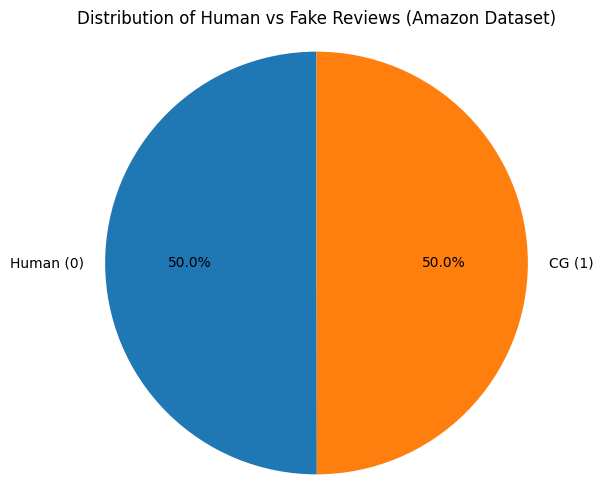

In [29]:
label_counts = amazon_df["label"].value_counts().sort_index()

# Pie chart
plt.figure(figsize=(6, 6))

plt.pie(
    label_counts,
    labels=["Human (0)", "CG (1)"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Human vs Fake Reviews (Amazon Dataset)")
plt.axis("equal")

plt.show()

In [30]:
label_counts = yelp_df["label"].value_counts().sort_index()

print(label_counts)

print("\nPercentage Distribution:")
print((label_counts / len(yelp_df) * 100).round(2))

label
0    321580
1     36576
Name: count, dtype: int64

Percentage Distribution:
label
0    89.79
1    10.21
Name: count, dtype: float64


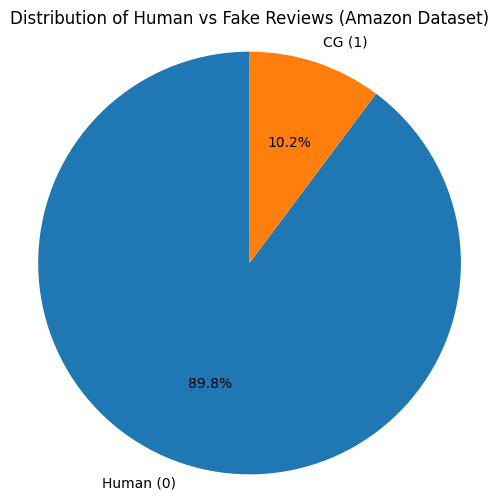

In [31]:
label_counts = yelp_df["label"].value_counts().sort_index()

# Pie chart
plt.figure(figsize=(6, 6))

plt.pie(
    label_counts,
    labels=["Human (0)", "CG (1)"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Human vs Fake Reviews (Amazon Dataset)")
plt.axis("equal")

plt.show()

#### Balance Yelp Dataset


randomly df 25k from each class to create a balanced subset, since the original Yelp data is heavily skewed (~90% genuine)

In [32]:
# fake = yelp_df[yelp_df['label'] == 0].df(n=25000, random_state=42)
# real = yelp_df[yelp_df['label'] == 1].df(n=25000, random_state=42)

# yelp_df = (
#     pd.concat([fake, real])
#       .df(frac=1, random_state=42)   # shuffle
#       .reset_index(drop=True)
# )
# print("Label counts:\n", yelp_df['label'].value_counts())

In [33]:
print("Label counts:\n", amazon_df['label'].value_counts())

Label counts:
 label
0    20215
1    20197
Name: count, dtype: int64


### Review Length Filtering

In [34]:
#amazon

print("Empty Reviews :", (amazon_df["review"] == "").sum())

print("Average Review Length :", amazon_df["review"].str.len().mean())

print("Shortest Review Length :", amazon_df["review"].str.len().min())

print("Longest Review Length :", amazon_df["review"].str.len().max())

Empty Reviews : 0
Average Review Length : 348.0739384341285
Shortest Review Length : 3
Longest Review Length : 2164


In [35]:
# Print rows where text has fewer than 20 characters
amazon_df[amazon_df["review"].str.len() < 20]

,rating,review,label
9907,5,<input,1
18615,3,Pfister LF-042-PRCC,1
36815,5,Nice elegant watch,1
37895,4,. .,1


In [36]:
amazon_df[amazon_df["review"].str.len() > 300]

,rating,review,label
2410,1,"I had a hard time contacting the manufacturer/distributor in order to make sure the measurements were correct. The description and the .pdf have completely different dimensions. In reality, these ...",0
2471,4,Works great. Plenty sharp and sets at a good angle for grating. The whole thing comes apart to make basically two different graters. I haven't had a problem with feeling cheap or feeling like it w...,0
2578,5,"I purchased this bed and have slept on it for the past week. I believe in trying things out to make sure my guests won't suffer from backaches, etc. The Aerobed provides a comfortable night's rest...",0
2605,4,"After my first night sleeping on a NeckBone pillow, I ordered another one so my husband could have his own, too. I could already feel improvement in my neck and shoulder problems after just one ni...",0
2607,5,These are great! I love them! Nice high quality silicone oven gloves! They are way easier to clean than a regular oven mitt! These can be thrown right in the dishwasher! They allow for full use of...,0
...,...,...,...
40407,4,I had read some reviews saying that this bra ran small and so I ordered TWO band AND cup sizes UP and it was still too small! Definitely along the lines of a sports bra squish effect. The sides do...,0
40408,5,"I wasn't sure exactly what it would be. It is a little large for my small size, but I think it is a nice fit. The fabric is a nice thin material, but it is a little thin in the legs. I wish it was...",1
40409,2,"You can wear the hood by itself, wear it with the hood, or wear just the jacket without the hood. How is that for 3-in-1 systems? Reminiscent of what Lands End sells as a ""Squall Jacket"", or what ...",0
40410,1,I liked nothing about this dress. The only reason I gave it 4 stars is because I ordered the size 6.5 and it fit perfectly. The fabric is a nice thin material and the color is vibrant. It's a litt...,1


In [37]:
long_reviews = amazon_df[amazon_df["review"].str.len() >300]

# Label counts
label_counts = long_reviews["label"].value_counts().sort_index()

print("Label Distribution (Count):")
print(label_counts)

print("\nLabel Distribution (Percentage):")
print((label_counts / len(long_reviews) * 100).round(2))

Label Distribution (Count):
label
0    7958
1    6352
Name: count, dtype: int64

Label Distribution (Percentage):
label
0    55.61
1    44.39
Name: count, dtype: float64


In [38]:
#yelp

print("Empty Reviews :", (yelp_df["review"] == "").sum())

print("Average Review Length :", yelp_df["review"].str.len().mean())

print("Shortest Review Length :", yelp_df["review"].str.len().min())

print("Longest Review Length :", yelp_df["review"].str.len().max())

Empty Reviews : 0
Average Review Length : 633.9931984945108
Shortest Review Length : 1
Longest Review Length : 5020


In [39]:
# Print rows where text has fewer than 20 characters
yelp_df[yelp_df["review"].str.len() < 20]

,rating,review,label
78,5,Very good food,0
405,5,Great italian food!,0
534,4,I am a fan!,1
778,4,pleasant surprise,0
879,5,Delicious dinner,0
...,...,...,...
357496,5,Cheap Indian food,0
357844,5,Get the brisket.,0
357849,5,best bbq EVER!,0
358008,4,Yummy Mojitos,0


In [40]:
short_yelp_reviews = yelp_df[yelp_df["review"].str.len() < 20]

# Label counts
label_counts = short_yelp_reviews["label"].value_counts().sort_index()

print("Label Distribution (Count):")
print(label_counts)

print("\nLabel Distribution (Percentage):")
print((label_counts / len(short_yelp_reviews) * 100).round(2))

Label Distribution (Count):
label
0    1245
1     565
Name: count, dtype: int64

Label Distribution (Percentage):
label
0    68.78
1    31.22
Name: count, dtype: float64


In [41]:
yelp_df[
    yelp_df["review"].str.len() < 20
].assign(
    review_length=yelp_df["review"].str.len()
).sort_values(
    by="review_length", ascending=False
)

,rating,review,label,review_length
3695,5,One word... Superb!,0,19
8036,5,Great Local place!!,0,19
141368,5,Definitely amazing.,0,19
143295,5,It's raining stars!,0,19
136951,5,Amazing pork tacos.,1,19
...,...,...,...,...
118526,5,!,0,1
21611,5,h,0,1
57002,3,I,0,1
144681,5,f,1,1


In [42]:
yelp_df[yelp_df["review"].str.len() > 500]

,rating,review,label
4,4,Snack is great place for a casual sit down lunch- especially on a cold winter day. In many ways the restaurant mirrors the food- simple yet unique. The avgolemono soup was lemony perfection and th...,1
6,4,"Let me start with a shout-out to everyone who is boosting the mint lemonade. That stuff is super tasty. I refuse to believe you can get fresher, more delicious Greek food for your dollar. I sport ...",1
8,4,"My friend and I were intrigued by the nightly entree special, ""Little Shoes,"" (eggplant stuffed with ground sirloin), and so we decided to eat at Snack. Although very tiny, we were able to stand w...",1
16,3,"This spot is close to my job so I decided to check it out for lunch. The prices are just about what you would expect for Soho/""South Village"" sit-down lunch prices; my meal came out to $20 for a m...",0
20,5,Some good Big Greek cooking!! Came to City on a gorgeous Sunday after a brutal winter one of the first clear sunny crisp Sundays to walk about Soho one of my fav's to do... And we were hungry and ...,0
...,...,...,...
358145,5,"Great Brooklyn vibe, excellent pizza, and a dessert to die for. What more can you ask for? I had the lavender lemonade and must say it's delicious--not too sweet, not too tart. My friend and I ord...",0
358149,5,Made a reservation for an early dinner Saturday night and was lucky enough to be seated in the back where we watched all the action unfold in the open kitchen. This was also a rustic and warm spot...,0
358150,5,"Emily is like Franny's Marco, but with warmth and value. Emily herself is so charming and the restaurant follows suit. Prices are reasonable here so you could eat a real meal for a real price. The...",0
358151,5,"I'm very spoiled with Pizza. Really, I have tried Lucali's, Di Fara's, John's at Bleekers, etc. Normally, I try the Margarita when I'm at a new place. It's just simple and if a place makes a good ...",0


When detecting AI-generated reviews, very short texts provide insufficient linguistic signal to reliably distinguish between human and AI.

In [43]:
yelp_df = yelp_df[yelp_df["review"].str.len() >= 20]

In [44]:
amazon_df=amazon_df[amazon_df["review"].str.len() >= 20]

In [45]:
#yelp

print("Empty Reviews :", (yelp_df["review"] == "").sum())

print("Average Review Length :", yelp_df["review"].str.len().mean())

print("Shortest Review Length :", yelp_df["review"].str.len().min())

print("Longest Review Length :", yelp_df["review"].str.len().max())

Empty Reviews : 0
Average Review Length : 637.146694504779
Shortest Review Length : 20
Longest Review Length : 5020


In [46]:
#amazon

print("Empty Reviews :", (amazon_df["review"] == "").sum())

print("Average Review Length :", amazon_df["review"].str.len().mean())

print("Shortest Review Length :", amazon_df["review"].str.len().min())

print("Longest Review Length :", amazon_df["review"].str.len().max())

Empty Reviews : 0
Average Review Length : 348.1072559889131
Shortest Review Length : 28
Longest Review Length : 2164


### Exploratory Data Analysis

In [47]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [48]:
#amazon

print("Dataset Shape :", amazon_df.shape)
print("\nClass Distribution:\n")
print(amazon_df["label"].value_counts())

amazon_df.head()

Dataset Shape : (40408, 3)

Class Distribution:

label
0    20215
1    20193
Name: count, dtype: int64


,rating,review,label
0,5,"Love this! Well made, sturdy, and very comfortable. I love it!Very pretty",1
1,5,"love it, a great upgrade from the original. I've had mine for a couple of years",1
2,5,This pillow saved my back. I love the look and feel of this pillow.,1
3,1,"Missing information on how to use it, but it is a great product for the price! I",1
4,5,Very nice set. Good quality. We have had the set for two months now and have not been,1


In [49]:
#Yelp

print("Dataset Shape :", yelp_df.shape)
print("\nClass Distribution:\n")
print(yelp_df["label"].value_counts())

yelp_df.head()

Dataset Shape : (356346, 3)

Class Distribution:

label
0    320335
1     36011
Name: count, dtype: int64


,rating,review,label
0,3,The food at snack is a selection of popular Greek dishes. The appetizer tray is good as is the Greek salad. We were underwhelmed with the main courses. There are 4-5 tables here so it's sometimes ...,1
1,3,"This little place in Soho is wonderful. I had a lamb sandwich and a glass of wine. The price shocked me for how small the serving was, but then again, this is Soho. The staff can be a little snott...",1
2,4,"ordered lunch for 15 from Snack last Friday. On time, nothing missing and the food was great. I have added it to the regular company lunch list, as everyone enjoyed their meal.",1
3,4,"This is a beautiful quaint little restaurant on a pretty street. If you're strolling through soho around lunchtime, this would be a great place to stop for a bite. I heard the reviews about the la...",1
4,4,Snack is great place for a casual sit down lunch- especially on a cold winter day. In many ways the restaurant mirrors the food- simple yet unique. The avgolemono soup was lemony perfection and th...,1


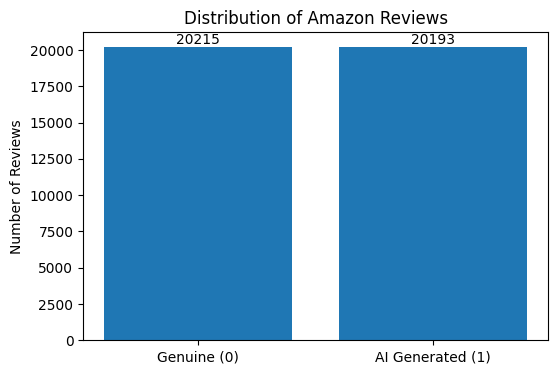

In [50]:
label_counts = amazon_df["label"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Genuine (0)", "AI Generated (1)"], label_counts.values)
plt.title("Distribution of Amazon Reviews")
plt.ylabel("Number of Reviews")

for i, value in enumerate(label_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.show()

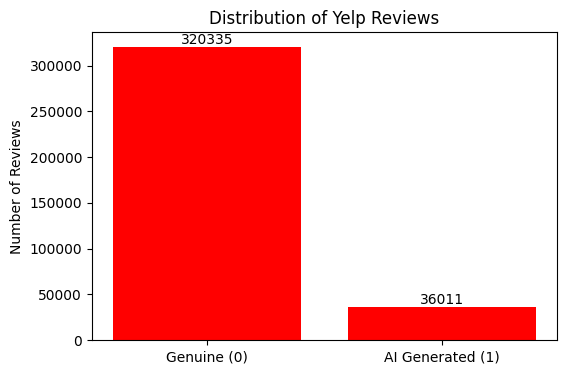

In [51]:
label_counts = yelp_df["label"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Genuine (0)", "AI Generated (1)"], label_counts.values,color="red")
plt.title("Distribution of Yelp Reviews")
plt.ylabel("Number of Reviews")

for i, value in enumerate(label_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.show()

### Feature Engineering

list the features being created: text_length, word_count, sentence_count, vocab_richness, avg_word_len

In [52]:
#feature engineering for amazon

amazon_df["text_length"] = amazon_df["review"].str.len()

amazon_df["word_count"] = amazon_df["review"].str.split().apply(len)

amazon_df["sentence_count"] = amazon_df["review"].apply(
    lambda x: len([s for s in nltk.sent_tokenize(x) if s.strip()])
)

amazon_df[["review","text_length", "word_count", "sentence_count"]].head()

,review,text_length,word_count,sentence_count
0,"Love this! Well made, sturdy, and very comfortable. I love it!Very pretty",73,12,3
1,"love it, a great upgrade from the original. I've had mine for a couple of years",79,16,2
2,This pillow saved my back. I love the look and feel of this pillow.,67,14,2
3,"Missing information on how to use it, but it is a great product for the price! I",80,17,2
4,Very nice set. Good quality. We have had the set for two months now and have not been,85,18,3


In [53]:
#feature engineering for yelp

yelp_df["text_length"] = yelp_df["review"].str.len()

yelp_df["word_count"] = yelp_df["review"].str.split().apply(len)

yelp_df["sentence_count"] = yelp_df["review"].apply(
    lambda x: len([s for s in nltk.sent_tokenize(x) if s.strip()])
)

yelp_df[["review","text_length", "word_count", "sentence_count"]].head()

,review,text_length,word_count,sentence_count
0,The food at snack is a selection of popular Greek dishes. The appetizer tray is good as is the Greek salad. We were underwhelmed with the main courses. There are 4-5 tables here so it's sometimes ...,215,40,4
1,"This little place in Soho is wonderful. I had a lamb sandwich and a glass of wine. The price shocked me for how small the serving was, but then again, this is Soho. The staff can be a little snott...",269,52,4
2,"ordered lunch for 15 from Snack last Friday. On time, nothing missing and the food was great. I have added it to the regular company lunch list, as everyone enjoyed their meal.",176,32,3
3,"This is a beautiful quaint little restaurant on a pretty street. If you're strolling through soho around lunchtime, this would be a great place to stop for a bite. I heard the reviews about the la...",489,90,7
4,Snack is great place for a casual sit down lunch- especially on a cold winter day. In many ways the restaurant mirrors the food- simple yet unique. The avgolemono soup was lemony perfection and th...,591,102,6


### Feature Distributions

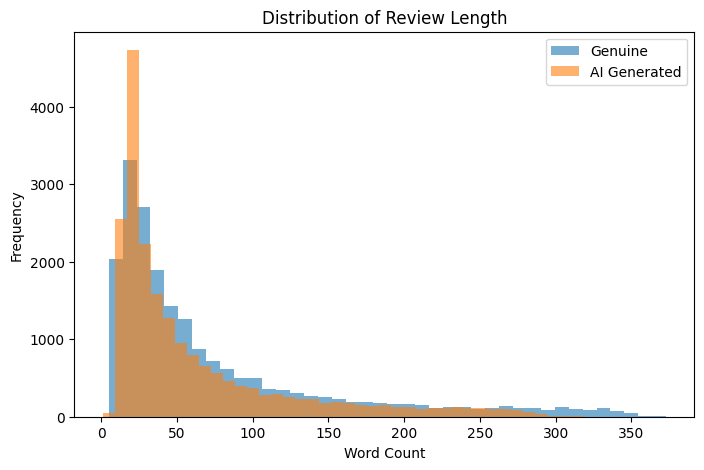

In [54]:
plt.figure(figsize=(8,5))

plt.hist(amazon_df[amazon_df["label"] == 0]["word_count"], bins=40, alpha=0.6, label="Genuine")

plt.hist(amazon_df[amazon_df["label"] == 1]["word_count"], bins=40, alpha=0.6, label="AI Generated")

plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Distribution of Review Length")
plt.legend()

plt.show()

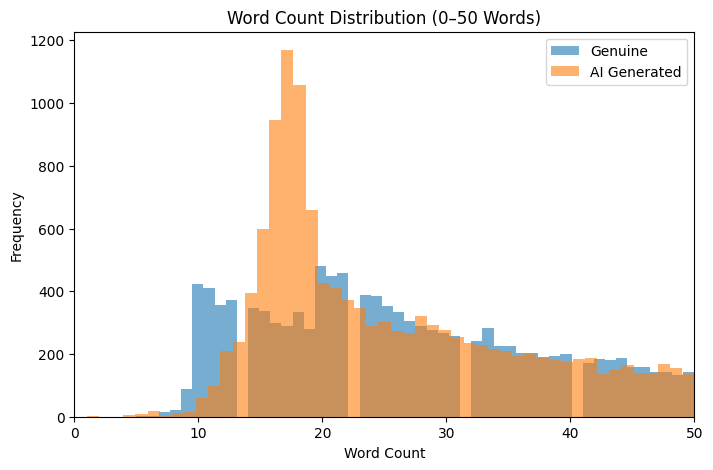

In [55]:
# Keep only reviews with <= 50 words
short_reviews = amazon_df[amazon_df["word_count"] <= 50]

plt.figure(figsize=(8,5))

plt.hist(
    short_reviews[short_reviews["label"] == 0]["word_count"],
    bins=50,                 # 1-word bins
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    short_reviews[short_reviews["label"] == 1]["word_count"],
    bins=50,
    alpha=0.6,
    label="AI Generated"
)

plt.xlim(0, 50)
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Word Count Distribution (0–50 Words)")
plt.legend()

plt.show()

In [56]:
# AI-generated reviews with 10–20 words
ai_reviews_10_20 = amazon_df[
    (amazon_df["label"] == 1) &
    (amazon_df["word_count"].between(10, 20))
]

# Display the relevant columns
ai_reviews_10_20[["review", "word_count"]]

,review,word_count
0,"Love this! Well made, sturdy, and very comfortable. I love it!Very pretty",12
1,"love it, a great upgrade from the original. I've had mine for a couple of years",16
2,This pillow saved my back. I love the look and feel of this pillow.,14
3,"Missing information on how to use it, but it is a great product for the price! I",17
4,Very nice set. Good quality. We have had the set for two months now and have not been,18
...,...,...
38270,"Twelve cotton bandannas in white! I love the look and fit of these! I am 5'6"" and the waistband",19
38273,LOVE these. Everyone has a different style. I've worn them for a couple of hours. They're comfortable and I don't,20
38274,"cute wings, but cheapy made-for-girls. Not worth it.Nice bag.Very pretty.I bought this for my son",15
38338,"Sent this back. Quality of material is great.Wife loved it.Nice bag!Very pretty.I bought this for my son, who lives in",20


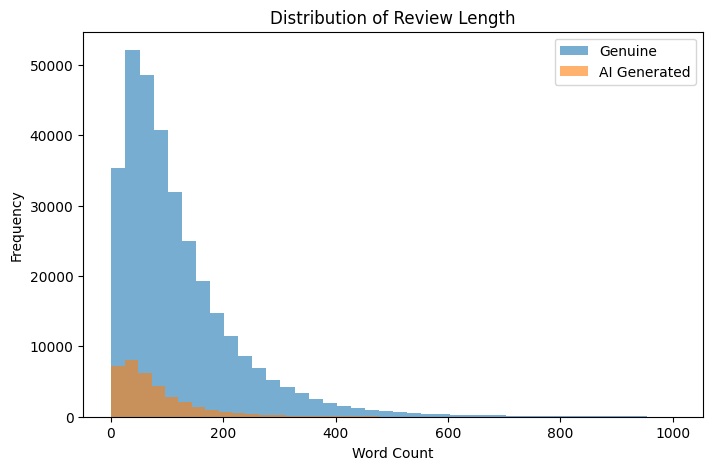

In [57]:
plt.figure(figsize=(8,5))

plt.hist(yelp_df[yelp_df["label"] == 0]["word_count"], bins=40, alpha=0.6, label="Genuine")

plt.hist(yelp_df[yelp_df["label"] == 1]["word_count"], bins=40, alpha=0.6, label="AI Generated")

plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Distribution of Review Length")
plt.legend()

plt.show()

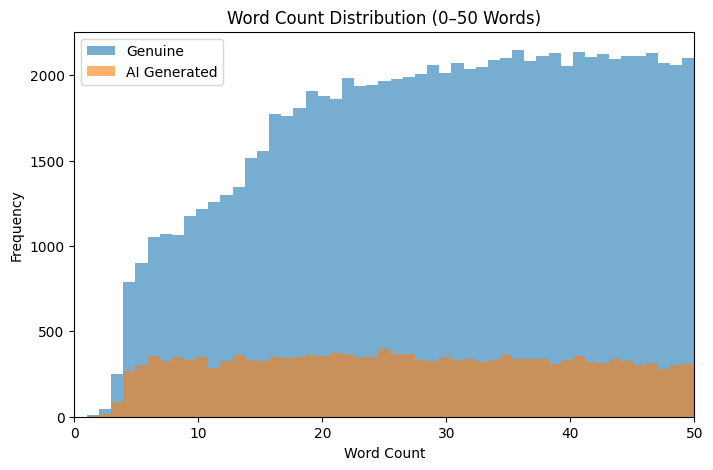

In [58]:
# Keep only reviews with <= 50 words
short_reviews = yelp_df[yelp_df["word_count"] <= 50]

plt.figure(figsize=(8,5))

plt.hist(
    short_reviews[short_reviews["label"] == 0]["word_count"],
    bins=50,                 # 1-word bins
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    short_reviews[short_reviews["label"] == 1]["word_count"],
    bins=50,
    alpha=0.6,
    label="AI Generated"
)

plt.xlim(0, 50)
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Word Count Distribution (0–50 Words)")
plt.legend()

plt.show()

In [59]:
# AI-generated reviews with 10–20 words
ai_reviews_10_20 = yelp_df[
    (yelp_df["label"] == 1) &
    (yelp_df["word_count"].between(10, 20))
]

# Display the relevant columns
ai_reviews_10_20[["review", "word_count"]]

,review,word_count
13,Perfection. Snack has become my favorite late lunch/early dinner spot. Make sure to try the butter beans!!!,17
216,"Pizza was not bad, however not great either. Prices are reasonable. I think they can work on there service.",19
222,The quattro stagioni reminds me of great pizzas from my childhood. I highly recommend this place for delivery.,18
224,Wonderfully delicious pizza! One of my favorite places to go in Brooklyn.,12
225,Pretty good cheesesteak subs. Pizza from a brick oven: a plus. Good service too.,14
...,...,...
356717,"We like it here a lot. Good food, pleasant atmosphere and good service.",13
356722,Very good food! The branzino wholefise is my favorite dish.,10
356723,this restaurant has such good food and the service great!!!,10
356745,best food on the UES...i could eat here every single day... DELICIOUS!!!! great service too,15


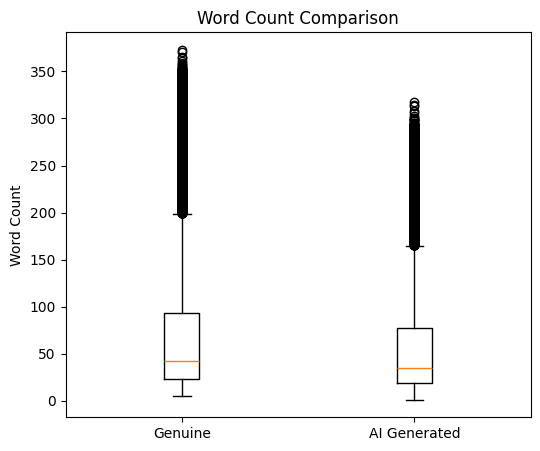

In [60]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [
        amazon_df[amazon_df["label"] == 0]["word_count"],
        amazon_df[amazon_df["label"] == 1]["word_count"]
    ],
    tick_labels=["Genuine", "AI Generated"]
)

plt.ylabel("Word Count")
plt.title("Word Count Comparison")

plt.show()

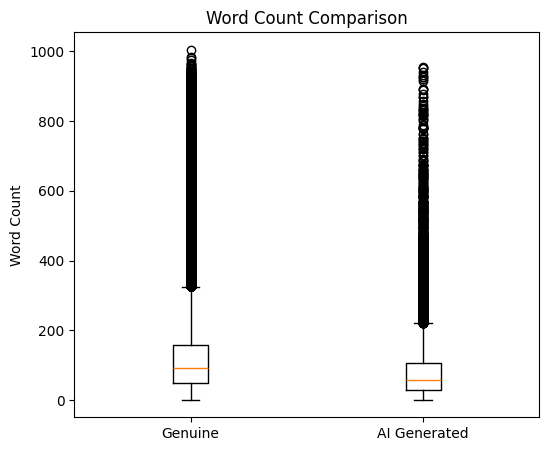

In [61]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [
        yelp_df[yelp_df["label"] == 0]["word_count"],
        yelp_df[yelp_df["label"] == 1]["word_count"]
    ],
    tick_labels=["Genuine", "AI Generated"]
)

plt.ylabel("Word Count")
plt.title("Word Count Comparison")

plt.show()

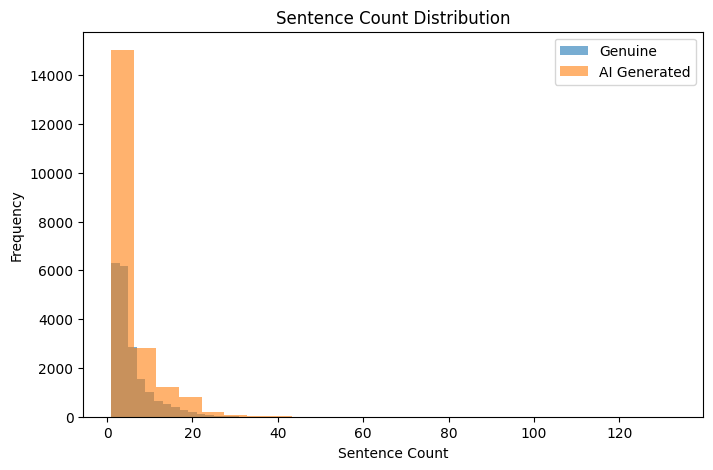

In [62]:
plt.figure(figsize=(8,5))

plt.hist(amazon_df[amazon_df["label"] == 0]["sentence_count"], bins=25, alpha=0.6, label="Genuine")

plt.hist(amazon_df[amazon_df["label"] == 1]["sentence_count"], bins=25, alpha=0.6, label="AI Generated")

plt.title("Sentence Count Distribution")
plt.xlabel("Sentence Count")
plt.ylabel("Frequency")
plt.legend()

plt.show()

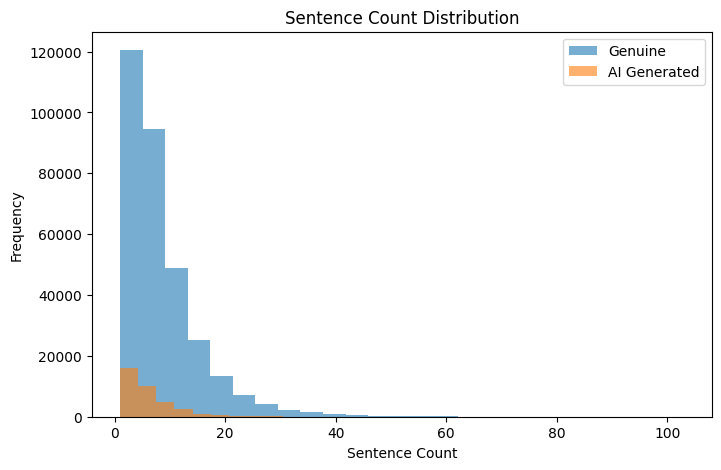

In [63]:
plt.figure(figsize=(8,5))

plt.hist(yelp_df[yelp_df["label"] == 0]["sentence_count"], bins=25, alpha=0.6, label="Genuine")

plt.hist(yelp_df[yelp_df["label"] == 1]["sentence_count"], bins=25, alpha=0.6, label="AI Generated")

plt.title("Sentence Count Distribution")
plt.xlabel("Sentence Count")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [64]:
def vocab_richness(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

amazon_df["vocab_richness"] = amazon_df["review"].apply(vocab_richness)

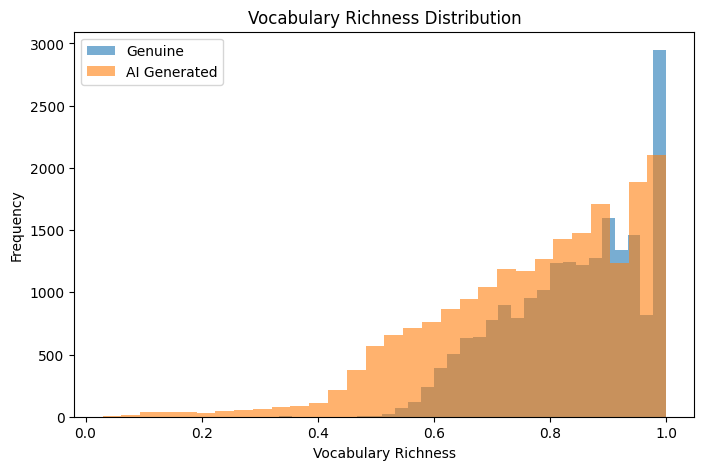

In [65]:
plt.figure(figsize=(8,5))

plt.hist(amazon_df[amazon_df["label"] == 0]["vocab_richness"], bins=30, alpha=0.6, label="Genuine")

plt.hist(amazon_df[amazon_df["label"] == 1]["vocab_richness"], bins=30, alpha=0.6, label="AI Generated")

plt.xlabel("Vocabulary Richness")
plt.ylabel("Frequency")
plt.title("Vocabulary Richness Distribution")
plt.legend()

plt.show()

In [66]:
def vocab_richness(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

yelp_df["vocab_richness"] = yelp_df["review"].apply(vocab_richness)

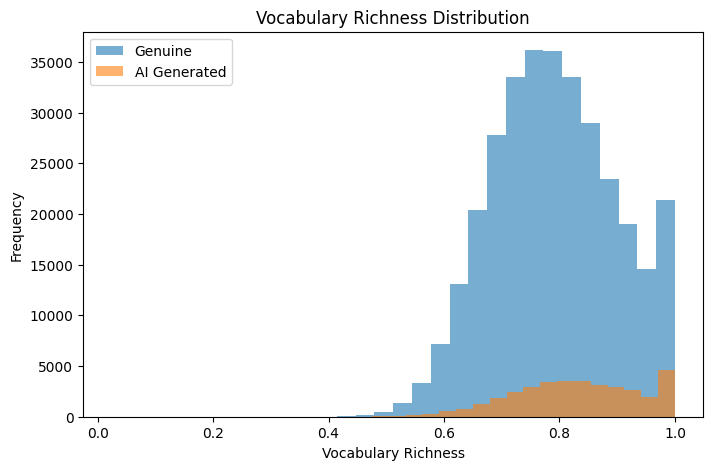

In [67]:
plt.figure(figsize=(8,5))

plt.hist(yelp_df[yelp_df["label"] == 0]["vocab_richness"], bins=30, alpha=0.6, label="Genuine")

plt.hist(yelp_df[yelp_df["label"] == 1]["vocab_richness"], bins=30, alpha=0.6, label="AI Generated")

plt.xlabel("Vocabulary Richness")
plt.ylabel("Frequency")
plt.title("Vocabulary Richness Distribution")
plt.legend()

plt.show()

In [68]:
def avg_word_length(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return np.mean([len(word) for word in words])

amazon_df["avg_word_len"] = amazon_df["review"].apply(avg_word_length)

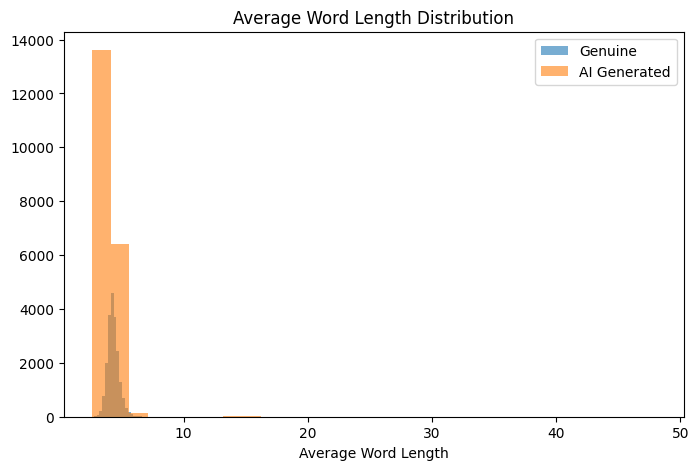

In [69]:
plt.figure(figsize=(8,5))

plt.hist(amazon_df[amazon_df["label"] == 0]["avg_word_len"], bins=30, alpha=0.6, label="Genuine")

plt.hist(amazon_df[amazon_df["label"] == 1]["avg_word_len"], bins=30, alpha=0.6, label="AI Generated")

plt.title("Average Word Length Distribution")
plt.xlabel("Average Word Length")
plt.legend()

plt.show()

In [70]:
def avg_word_length(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return np.mean([len(word) for word in words])

yelp_df["avg_word_len"] = yelp_df["review"].apply(avg_word_length)

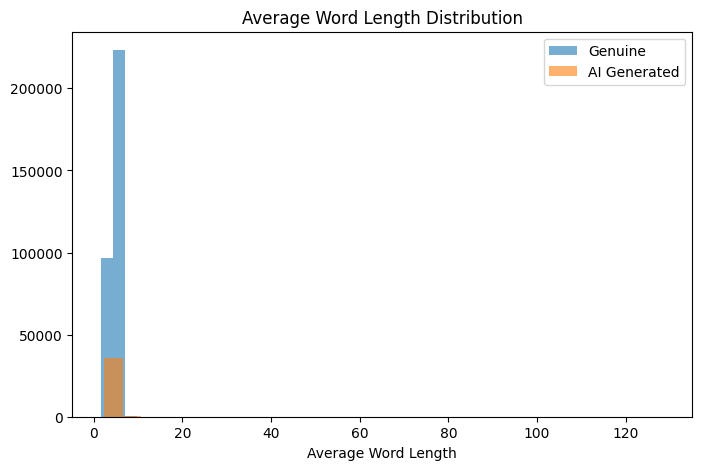

In [71]:
plt.figure(figsize=(8,5))

plt.hist(yelp_df[yelp_df["label"] == 0]["avg_word_len"], bins=30, alpha=0.6, label="Genuine")

plt.hist(yelp_df[yelp_df["label"] == 1]["avg_word_len"], bins=30, alpha=0.6, label="AI Generated")

plt.title("Average Word Length Distribution")
plt.xlabel("Average Word Length")
plt.legend()

plt.show()

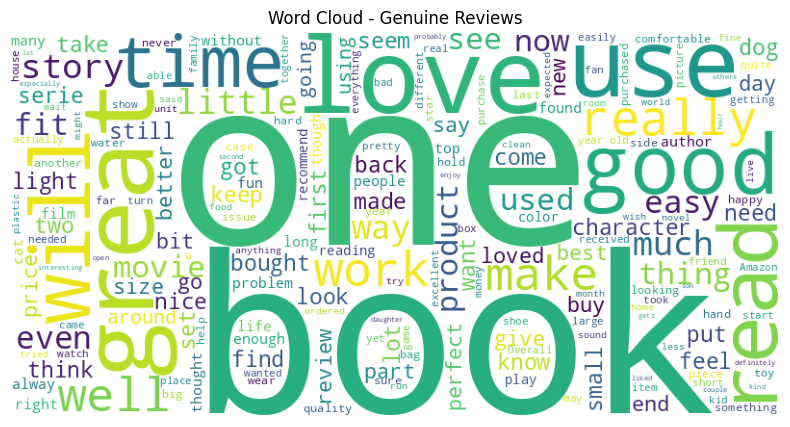

In [72]:
genuine_text = " ".join(amazon_df[amazon_df["label"] == 0]["review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(genuine_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - Genuine Reviews")
plt.show()

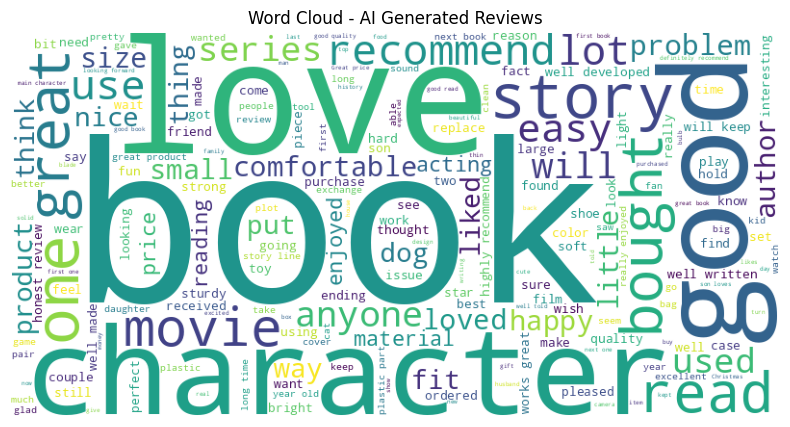

In [73]:
fake_text = " ".join(amazon_df[amazon_df["label"] == 1]["review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(fake_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - AI Generated Reviews")
plt.show()

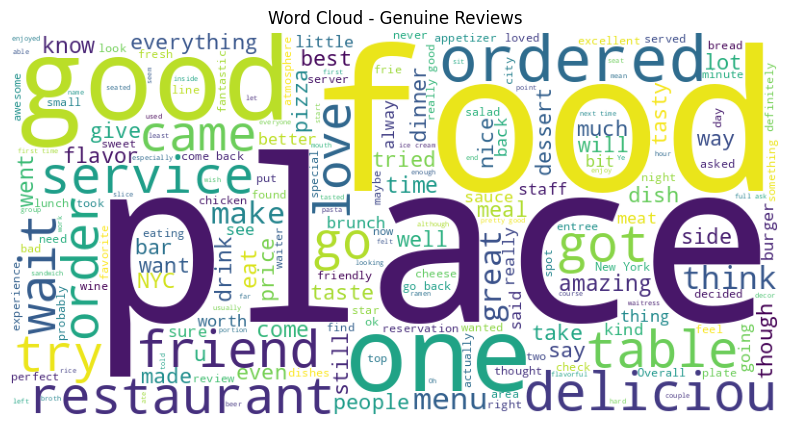

In [74]:
genuine_text = " ".join(yelp_df[yelp_df["label"] == 0]["review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(genuine_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - Genuine Reviews")
plt.show()

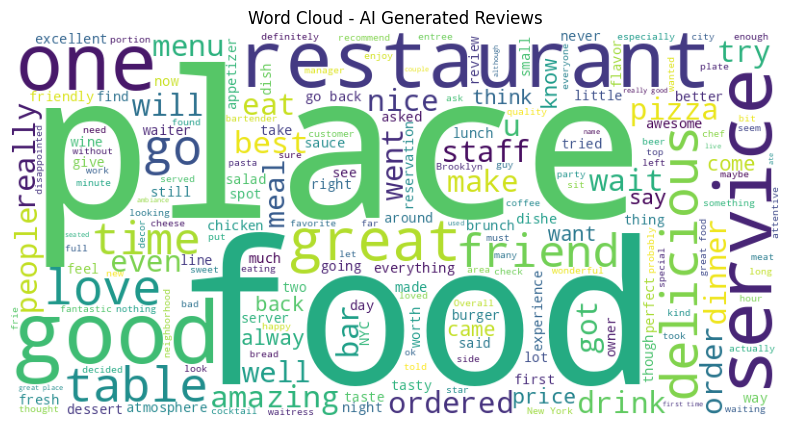

In [75]:
fake_text = " ".join(yelp_df[yelp_df["label"] == 1]["review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(fake_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - AI Generated Reviews")
plt.show()

In [76]:
def plot_top_words(dataframe, label, title):
    vectorizer = CountVectorizer(stop_words="english", max_features=20)

    X = vectorizer.fit_transform(dataframe[dataframe["label"] == label]["review"])

    counts = np.asarray(X.sum(axis=0)).flatten()

    words = vectorizer.get_feature_names_out()

    pairs = sorted(zip(words, counts), key=lambda x: x[1], reverse=True)

    words, counts = zip(*pairs)

    plt.figure(figsize=(8,6))
    plt.barh(words, counts)
    plt.title(title)
    plt.xlabel("Frequency")
    plt.gca().invert_yaxis()
    plt.show()

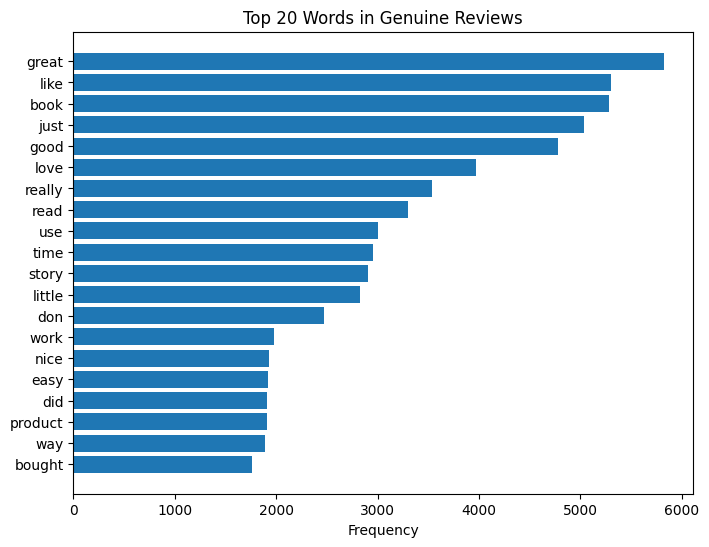

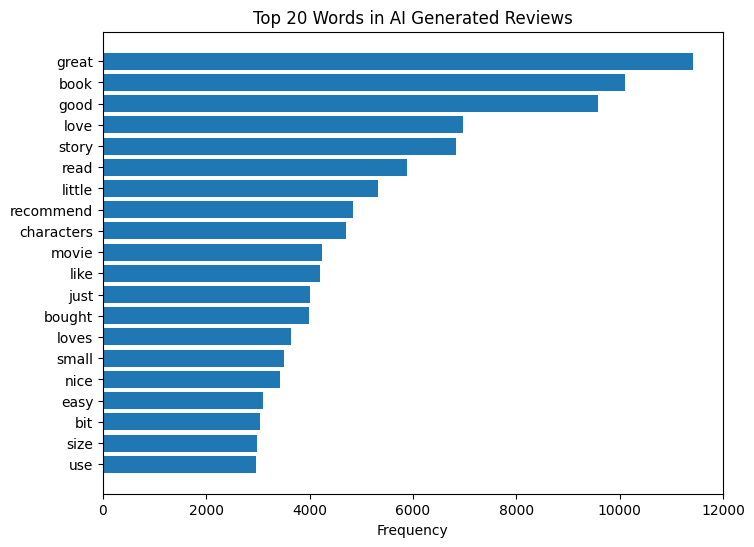

In [77]:
plot_top_words(amazon_df, 0, "Top 20 Words in Genuine Reviews")

plot_top_words(amazon_df, 1, "Top 20 Words in AI Generated Reviews")

In [78]:
amazon_df[
    amazon_df["review"].str.contains(r"\bcharacters\b", case=False, na=False)
][["review", "label", "word_count"]].sample(10, random_state=42)

,review,label,word_count
25740,I enjoyed this werewolf story. The heroine is a wonderful character and her son's are sure to be strong characters in future books. The hero is a well rounded character as well and I look forward ...,0,48
24464,I enjoyed the story. I loved the characters. I loved the history. I enjoyed the way the author portrayed the characters.,1,21
15012,This is a terrfic series that has the characters and plots of a science fiction story. It has the appearance of a very dark and disturbing world. The characters are not the same as the original mo...,1,155
31165,"Rick Bragg is one of the most entertaining characters I've read in a long time. This is a very well-written book, and I am sure you'll enjoy it as much as I do. It's a very well-written story, and...",1,60
27064,"Very good book and for a beginner, the writing is good. There is a lot of detail and so on. I liked how the characters were developed, the story line was interesting, and the characters were well ...",1,88
15028,"This movie is available in both English and French, which is a nice bonus. I recommend it.I really enjoyed the movie. The characters and the story were great. The acting was great. The acting was ...",1,140
15283,"Dirty Harry is more than a little predictable. The two main characters are just too predictable and predictable. The movie is also a bit too long, and the first half is pretty straight forward. Th...",1,197
26227,"No one includes a better mix of action, adventure, romance, and humor in one story than Patti Larsen and this installment of the Blood & Gold series is no different. I love Larsen's writing and ch...",0,63
24942,I have enjoyed this author's work. The characters are well developed and the story is well told. The story is well-written. The characters are well-,1,25
25639,Wow this was an awesome book. The characters were well developed and I enjoyed the story. The writing is well done. The story is well told and the flow of the story is well developed. The author d...,1,42


In [79]:
# Reviews containing the word "characters"
characters_reviews = amazon_df[
    amazon_df["review"].str.contains(r"\bcharacters\b", case=False, na=False)
]

# Count of Genuine (0) and AI Generated (1)
label_counts = characters_reviews["label"].value_counts().sort_index()

print("Label Distribution:")
print(label_counts)

print("\nPercentage Distribution:")
print((label_counts / len(characters_reviews) * 100).round(2))

Label Distribution:
label
0    1130
1    2567
Name: count, dtype: int64

Percentage Distribution:
label
0    30.57
1    69.43
Name: count, dtype: float64


In [80]:
# Reviews containing the word "recommend"
recommend_reviews = amazon_df[
    amazon_df["review"].str.contains(r"\brecommend\b", case=False, na=False)
]

# Count of Genuine (0) and AI Generated (1)
label_counts = recommend_reviews["label"].value_counts().sort_index()

print("Label Distribution:")
print(label_counts)

print("\nPercentage Distribution:")
print((label_counts / len(recommend_reviews) * 100).round(2))

Label Distribution:
label
0    1373
1    3424
Name: count, dtype: int64

Percentage Distribution:
label
0    28.62
1    71.38
Name: count, dtype: float64


These 2 words recommend and characters where very prominently used by AI to write the review on the other hand humans didn't use these words as much.

Side Note: - This also tells us one thing without checking the category in which fake reviews are more common than the others. Since, "characters" word were used so often by AI its safe to say AI generated reviews are very common in books category.

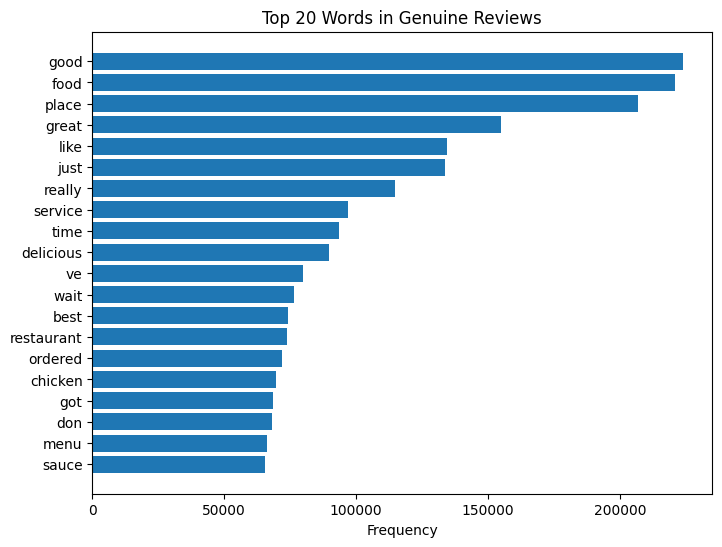

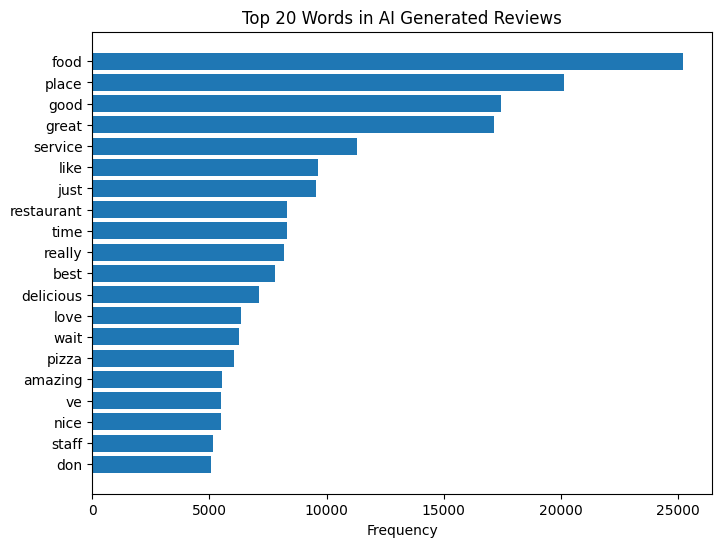

In [81]:
plot_top_words(yelp_df, 0, "Top 20 Words in Genuine Reviews")

plot_top_words(yelp_df, 1, "Top 20 Words in AI Generated Reviews")

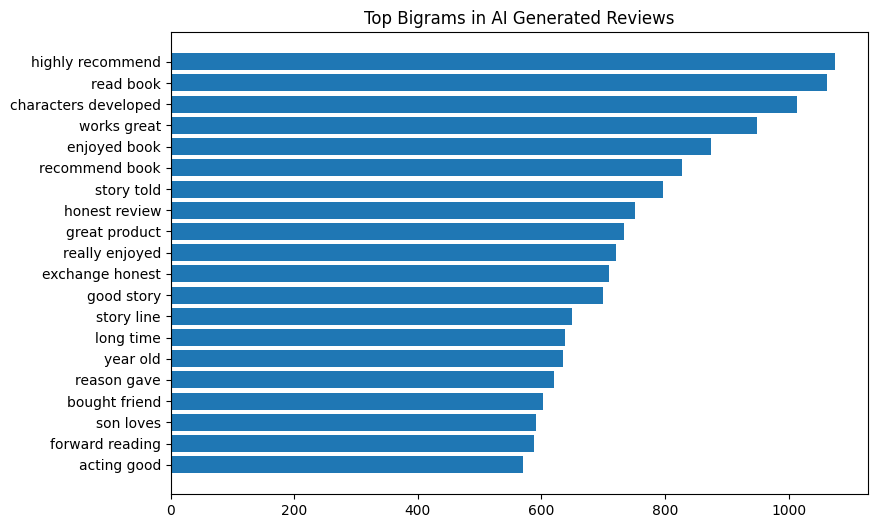

In [82]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(amazon_df[amazon_df["label"] == 1]["review"])

counts = np.asarray(X.sum(axis=0)).flatten()

bigrams = vectorizer.get_feature_names_out()

pairs = sorted(zip(bigrams, counts), key=lambda x: x[1], reverse=True)

bigrams, counts = zip(*pairs)

plt.figure(figsize=(9,6))
plt.barh(bigrams, counts)
plt.title("Top Bigrams in AI Generated Reviews")
plt.gca().invert_yaxis()
plt.show()

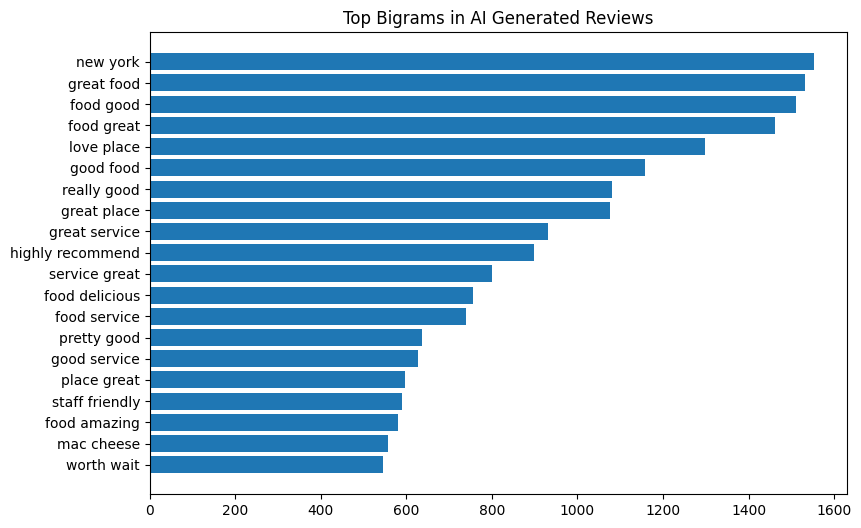

In [83]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(yelp_df[yelp_df["label"] == 1]["review"])

counts = np.asarray(X.sum(axis=0)).flatten()

bigrams = vectorizer.get_feature_names_out()

pairs = sorted(zip(bigrams, counts), key=lambda x: x[1], reverse=True)

bigrams, counts = zip(*pairs)

plt.figure(figsize=(9,6))
plt.barh(bigrams, counts)
plt.title("Top Bigrams in AI Generated Reviews")
plt.gca().invert_yaxis()
plt.show()

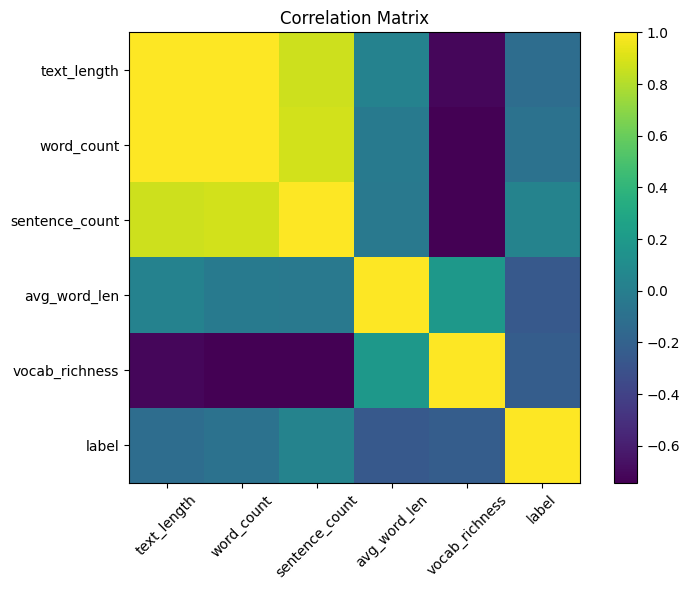

In [84]:
feature_cols = [
    "text_length",
    "word_count",
    "sentence_count",
    "avg_word_len",
    "vocab_richness",
    "label"
]

corr = amazon_df[feature_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(feature_cols)), feature_cols, rotation=45)

plt.yticks(range(len(feature_cols)), feature_cols)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

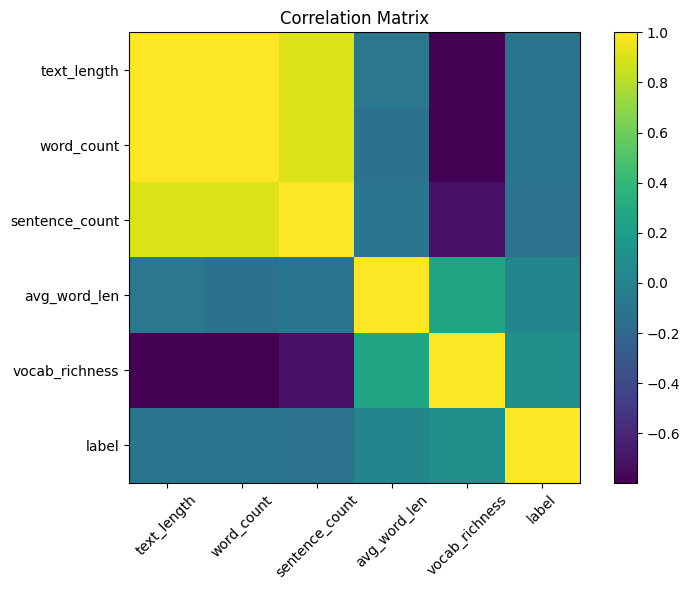

In [85]:
feature_cols = [
    "text_length",
    "word_count",
    "sentence_count",
    "avg_word_len",
    "vocab_richness",
    "label"
]

corr = yelp_df[feature_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(feature_cols)), feature_cols, rotation=45)

plt.yticks(range(len(feature_cols)), feature_cols)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [86]:
summary = amazon_df.groupby("label")[
    [
        "text_length",
        "word_count",
        "sentence_count",
        "avg_word_len",
        "vocab_richness"
    ]
].describe()

summary

text_length                                                             \
            count        mean         std   min    25%    50%    75%     max   
label                                                                          
0         20215.0  393.292753  412.170931  28.0  120.0  223.0  495.0  2164.0   
1         20193.0  302.872530  304.555406  41.0   95.0  173.0  379.0  1717.0   

      word_count                                                      \
           count       mean        std  min   25%   50%   75%    max   
label                                                                  
0        20215.0  73.609300  76.025886  5.0  23.0  42.0  93.0  373.0   
1        20193.0  61.297331  61.827741  1.0  19.0  35.0  77.0  318.0   

      sentence_count                                                 \
               count      mean       std  min  25%  50%  75%    max   
label                                                                 
0            20215.0  5.098244  4.481379  1.0  2.0  4.0  6.0   51.0   
1            20193.0  5.451394  5.306347  1.0  2.0  3.0  7.0  133.0   

      avg_word_len                                                    \
             count      mean       std       min       25%       50%   
label                                                                  
0          20215.0  4.346414  0.465506  2.777778  4.047059  4.305556   
1          20193.0  4.032499  0.683346  2.611111  3.730263  3.950000   

                      vocab_richness                                          \
            75%   max          count      mean       std       min       25%   
label                                                                          
0      4.600000   9.6        20215.0  0.840035  0.117297  0.333333  0.754098   
1      4.222222  48.0        20193.0  0.769459  0.173336  0.029412  0.654321   

                                
            50%       75%  max  
label                           
0      0.854167  0.933333  1.0  
1      0.800000  0.909091  1.0

In [87]:
amazon_df.groupby("label")["vocab_richness"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,20215.0,0.840035,0.117297,0.333333,0.754098,0.854167,0.933333,1.0
1,20193.0,0.769459,0.173336,0.029412,0.654321,0.800000,0.909091,1.0


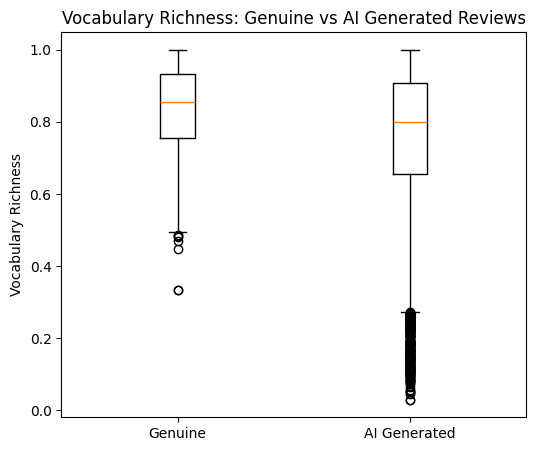

In [88]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [
        amazon_df[amazon_df["label"] == 0]["vocab_richness"],
        amazon_df[amazon_df["label"] == 1]["vocab_richness"]
    ],
    tick_labels=["Genuine", "AI Generated"]
)

plt.title("Vocabulary Richness: Genuine vs AI Generated Reviews")
plt.ylabel("Vocabulary Richness")

plt.show()

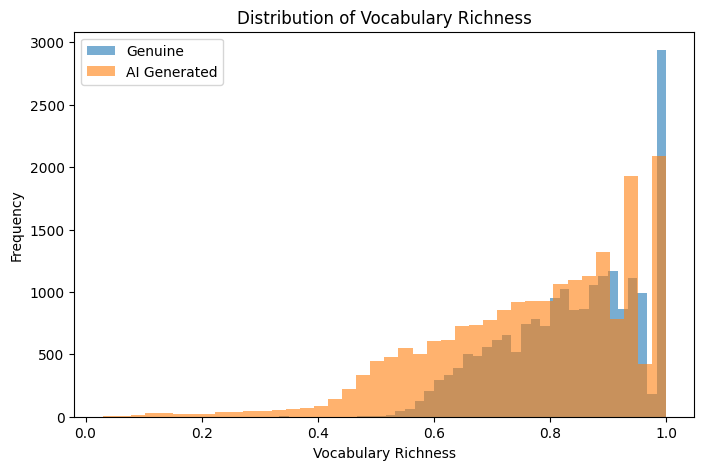

In [89]:
plt.figure(figsize=(8,5))

plt.hist(
    amazon_df[amazon_df["label"] == 0]["vocab_richness"],
    bins=40,
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    amazon_df[amazon_df["label"] == 1]["vocab_richness"],
    bins=40,
    alpha=0.6,
    label="AI Generated"
)

plt.xlabel("Vocabulary Richness")
plt.ylabel("Frequency")
plt.title("Distribution of Vocabulary Richness")
plt.legend()

plt.show()

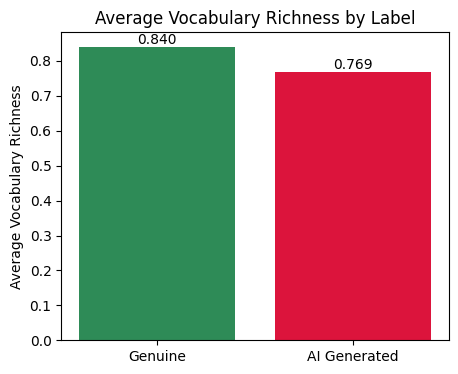

In [90]:
vocab_mean = amazon_df.groupby("label")["vocab_richness"].mean()

plt.figure(figsize=(5,4))

plt.bar(
    ["Genuine", "AI Generated"],
    vocab_mean.values,
    color=["#2E8B57", "#DC143C"]
)

plt.ylabel("Average Vocabulary Richness")
plt.title("Average Vocabulary Richness by Label")

for i, value in enumerate(vocab_mean.values):
    plt.text(i, value, f"{value:.3f}", ha="center", va="bottom")

plt.show()

This is interesting AI reviews have lower vocab richness than i thought would be the case.<br>
A guess i can take is in order to look like geniune ai generated review might delibratly reduce their own vocabulary.<br>
looking at the box plot and distribution graph. i believe my assumption is correct since human reviews didnt fall below a certain point(0.3). and even in the range of 0.3 there were very few examples which we can also rule as outliers.

In [91]:
summary = yelp_df.groupby("label")[
    [
        "text_length",
        "word_count",
        "sentence_count",
        "avg_word_len",
        "vocab_richness"
    ]
].describe()

summary

text_length                                                             \
            count        mean         std   min    25%    50%    75%     max   
label                                                                          
0        320335.0  658.216639  589.291162  20.0  262.0  491.0  862.0  5002.0   
1         36011.0  449.719502  459.362625  20.0  162.0  316.0  574.0  5020.0   

      word_count                                                          \
           count        mean         std  min   25%   50%    75%     max   
label                                                                      
0       320335.0  121.084752  108.144113  1.0  48.0  91.0  159.0  1004.0   
1        36011.0   82.902058   85.002123  1.0  29.0  58.0  106.0   955.0   

      sentence_count                                                  \
               count      mean       std  min  25%  50%   75%    max   
label                                                                  
0           320335.0  8.824577  7.000755  1.0  4.0  7.0  11.0  103.0   
1            36011.0  6.277665  5.281434  1.0  3.0  5.0   8.0   83.0   

      avg_word_len                                                    \
             count      mean       std       min       25%       50%   
label                                                                  
0         320335.0  4.503269  0.505167  1.534247  4.247619  4.446809   
1          36011.0  4.538251  1.019431  2.285714  4.210843  4.450000   

                            vocab_richness                               \
            75%         max          count      mean       std      min   
label                                                                     
0      4.678571   84.250000       320335.0  0.791729  0.108000  0.02381   
1      4.737500  128.666667        36011.0  0.830641  0.109477  0.12500   

                                          
            25%       50%       75%  max  
label                                     
0      0.713542  0.787234  0.867925  1.0  
1      0.753659  0.830986  0.914286  1.0

In [92]:
yelp_df.groupby("label")["vocab_richness"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,320335.0,0.791729,0.108000,0.02381,0.713542,0.787234,0.867925,1.0
1,36011.0,0.830641,0.109477,0.12500,0.753659,0.830986,0.914286,1.0


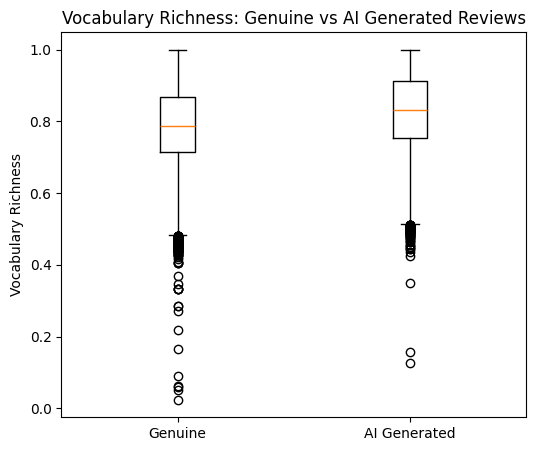

In [93]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [
        yelp_df[yelp_df["label"] == 0]["vocab_richness"],
        yelp_df[yelp_df["label"] == 1]["vocab_richness"]
    ],
    tick_labels=["Genuine", "AI Generated"]
)

plt.title("Vocabulary Richness: Genuine vs AI Generated Reviews")
plt.ylabel("Vocabulary Richness")

plt.show()

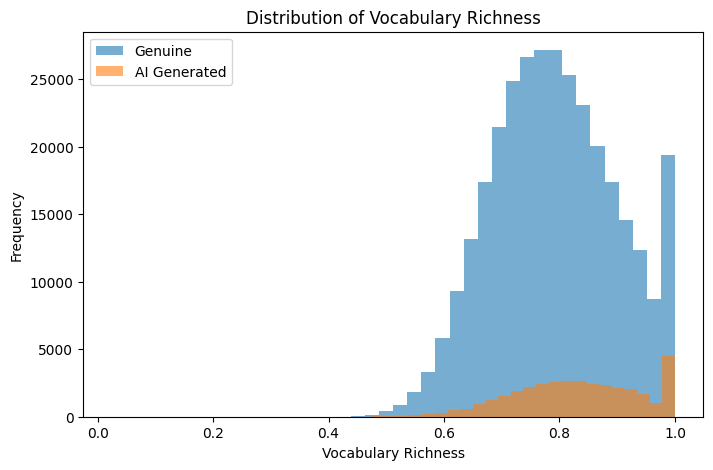

In [94]:
plt.figure(figsize=(8,5))

plt.hist(
    yelp_df[yelp_df["label"] == 0]["vocab_richness"],
    bins=40,
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    yelp_df[yelp_df["label"] == 1]["vocab_richness"],
    bins=40,
    alpha=0.6,
    label="AI Generated"
)

plt.xlabel("Vocabulary Richness")
plt.ylabel("Frequency")
plt.title("Distribution of Vocabulary Richness")
plt.legend()

plt.show()

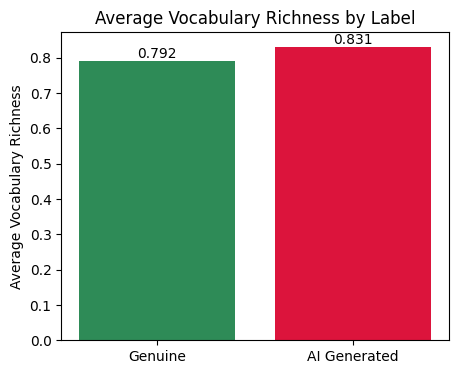

In [95]:
vocab_mean = yelp_df.groupby("label")["vocab_richness"].mean()

plt.figure(figsize=(5,4))

plt.bar(
    ["Genuine", "AI Generated"],
    vocab_mean.values,
    color=["#2E8B57", "#DC143C"]
)

plt.ylabel("Average Vocabulary Richness")
plt.title("Average Vocabulary Richness by Label")

for i, value in enumerate(vocab_mean.values):
    plt.text(i, value, f"{value:.3f}", ha="center", va="bottom")

plt.show()

The Yelp dataset shows a different pattern from the Amazon dataset. Overall, AI-generated reviews have higher vocabulary richness than genuine human reviews, suggesting they tend to use a wider variety of unique words.<br>

However, genuine human reviews still follow a consistent distribution. From the box plot and histogram, most human reviews do not have a vocabulary richness below 0.4, with only a small number of reviews falling below this threshold. These can reasonably be treated as outliers rather than the general behavior of human-written reviews.

### Feature Engineering

In [96]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import string

In [97]:
VOCAB_THRESHOLD = 0.40

def punctuation_count(review):
    return sum(char in string.punctuation for char in review)

def uppercase_ratio(review):
    if len(review) == 0:
        return 0
    upper = sum(char.isupper() for char in review)
    return upper / len(review)

def digit_count(review):
    return sum(char.isdigit() for char in review)

def avg_sentence_length(review):
    sentences = [
        s for s in review.replace("!", ".").replace("?", ".").split(".")
        if s.strip()
    ]

    if len(sentences) == 0:
        return 0

    return np.mean([len(sentence.split()) for sentence in sentences])

In [98]:
def engineer_metadata(dataset):
    dataset = dataset.copy()

    dataset["punctuation_count"] = dataset["review"].apply(punctuation_count)

    dataset["uppercase_ratio"] = dataset["review"].apply(uppercase_ratio)

    dataset["digit_count"] = dataset["review"].apply(digit_count)

    dataset["avg_sentence_length"] = dataset["review"].apply(avg_sentence_length)

    dataset["low_vocab_richness"] = (
        dataset["vocab_richness"] < VOCAB_THRESHOLD
    ).astype(int)

    return dataset


amazon_df = engineer_metadata(amazon_df)
yelp_df = engineer_metadata(yelp_df)

In [99]:
metadata_columns = [
    "text_length",
    "word_count",
    "sentence_count",
    "avg_word_len",
    "vocab_richness",
    "low_vocab_richness",
    "punctuation_count",
    "uppercase_ratio",
    "digit_count",
    "avg_sentence_length"
]

print("Amazon Dataset Metadata Features")
display(amazon_df[metadata_columns].head())

print("\nYelp Dataset Metadata Features")
display(yelp_df[metadata_columns].head())

Amazon Dataset Metadata Features


,text_length,word_count,sentence_count,avg_word_len,vocab_richness,low_vocab_richness,punctuation_count,uppercase_ratio,digit_count,avg_sentence_length
0,73,12,3,5.166667,1.000000,0,5,0.054795,0,3.25
1,79,16,2,4.000000,0.937500,0,3,0.012658,0,8.00
2,67,14,2,3.857143,1.000000,0,2,0.029851,0,7.00
3,80,17,2,3.764706,1.000000,0,2,0.025000,0,8.50
4,85,18,3,3.777778,0.944444,0,2,0.035294,0,6.00



Yelp Dataset Metadata Features


,text_length,word_count,sentence_count,avg_word_len,vocab_richness,low_vocab_richness,punctuation_count,uppercase_ratio,digit_count,avg_sentence_length
0,215,40,4,4.400000,0.875000,0,6,0.027907,2,10.000000
1,269,52,4,4.192308,0.826923,0,10,0.022305,0,13.000000
2,176,32,3,4.531250,0.937500,0,5,0.022727,2,10.666667
3,489,90,7,4.444444,0.755556,0,14,0.016360,0,12.857143
4,591,102,6,4.803922,0.833333,0,18,0.016920,0,13.000000


In [100]:
print("Amazon Missing Values")
display(amazon_df[metadata_columns].isnull().sum())

print("\nYelp Missing Values")
display(yelp_df[metadata_columns].isnull().sum())

Amazon Missing Values


text_length            0
word_count             0
sentence_count         0
avg_word_len           0
vocab_richness         0
low_vocab_richness     0
punctuation_count      0
uppercase_ratio        0
digit_count            0
avg_sentence_length    0
dtype: int64


Yelp Missing Values


text_length            0
word_count             0
sentence_count         0
avg_word_len           0
vocab_richness         0
low_vocab_richness     0
punctuation_count      0
uppercase_ratio        0
digit_count            0
avg_sentence_length    0
dtype: int64

In [101]:
print("Amazon Feature Statistics")
display(amazon_df[metadata_columns].describe().T)

print("\nYelp Feature Statistics")
display(yelp_df[metadata_columns].describe().T)

Amazon Feature Statistics


,count,mean,std,min,25%,50%,75%,max
text_length,40408.0,348.107256,365.213892,28.000000,106.000000,197.000000,435.000000,2164.000000
word_count,40408.0,67.456667,69.567331,1.000000,21.000000,39.000000,85.000000,373.000000
sentence_count,40408.0,5.274723,4.914104,1.000000,2.000000,3.000000,6.000000,133.000000
avg_word_len,40408.0,4.189542,0.605300,2.611111,3.851196,4.125000,4.450000,48.000000
vocab_richness,40408.0,0.804766,0.152126,0.029412,0.709677,0.830508,0.925926,1.000000
low_vocab_richness,40408.0,0.012794,0.112388,0.000000,0.000000,0.000000,0.000000,1.000000
punctuation_count,40408.0,9.897199,11.451435,0.000000,3.000000,6.000000,12.000000,199.000000
uppercase_ratio,40408.0,0.030838,0.047978,0.000000,0.018888,0.024691,0.032967,0.847458
digit_count,40408.0,1.066497,3.392762,0.000000,0.000000,0.000000,1.000000,155.000000
avg_sentence_length,40408.0,11.997829,6.146286,1.000000,8.500000,11.000000,14.400000,241.000000



Yelp Feature Statistics


,count,mean,std,min,25%,50%,75%,max
text_length,356346.0,637.146695,580.898968,20.000000,249.000000,470.000000,834.000000,5020.000000
word_count,356346.0,117.226151,106.657727,1.000000,45.000000,87.000000,154.000000,1004.000000
sentence_count,356346.0,8.567196,6.889540,1.000000,4.000000,7.000000,11.000000,103.000000
avg_word_len,356346.0,4.506805,0.578390,1.534247,4.244094,4.446970,4.684211,128.666667
vocab_richness,356346.0,0.795661,0.108784,0.023810,0.716981,0.791667,0.873016,1.000000
low_vocab_richness,356346.0,0.000053,0.007302,0.000000,0.000000,0.000000,0.000000,1.000000
punctuation_count,356346.0,21.548419,20.997048,0.000000,8.000000,15.000000,28.000000,713.000000
uppercase_ratio,356346.0,0.028824,0.021692,0.000000,0.018433,0.024490,0.033333,0.730159
digit_count,356346.0,1.839241,3.513036,0.000000,0.000000,0.000000,2.000000,242.000000
avg_sentence_length,356346.0,12.718823,5.829129,1.000000,9.300000,12.090909,15.272727,323.000000


In [102]:
def vocab_threshold_analysis(dataset, name):
    summary = (
        dataset.groupby("label")["low_vocab_richness"]
        .agg(["sum", "count", "mean"])
        .rename(columns={
            "sum": "Below Threshold",
            "count": "Total Reviews",
            "mean": "Percentage Below Threshold"
        })
    )

    summary["Percentage Below Threshold"] *= 100

    print(f"\n{name} Dataset")
    display(summary.round(2))

vocab_threshold_analysis(amazon_df, "Amazon")
vocab_threshold_analysis(yelp_df, "Yelp")


Amazon Dataset


,Below Threshold,Total Reviews,Percentage Below Threshold
label,,,
0,2,20215,0.01
1,515,20193,2.55



Yelp Dataset


,Below Threshold,Total Reviews,Percentage Below Threshold
label,,,
0,16,320335,0.00
1,3,36011,0.01


In [103]:
X_amazon_metadata = amazon_df[metadata_columns].copy()
y_amazon = amazon_df["label"].copy()

X_yelp_metadata = yelp_df[metadata_columns].copy()
y_yelp = yelp_df["label"].copy()

print("Amazon Metadata Shape:", X_amazon_metadata.shape)
print("Yelp Metadata Shape:", X_yelp_metadata.shape)

Amazon Metadata Shape: (40408, 10)
Yelp Metadata Shape: (356346, 10)


In [104]:
X_amazon_text = amazon_df["review"].copy()
X_yelp_text = yelp_df["review"].copy()

print("Amazon Reviews:", len(X_amazon_text))
print("Yelp Reviews:", len(X_yelp_text))

Amazon Reviews: 40408
Yelp Reviews: 356346


In [105]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

# TF-IDF fitted ONLY on Amazon reviews
tfidf_amazon = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english"
)

X_amazon_tfidf = tfidf_amazon.fit_transform(X_amazon_text)
X_yelp_tfidf = tfidf_amazon.transform(X_yelp_text)

print("Amazon TF-IDF Shape:", X_amazon_tfidf.shape)
print("Yelp TF-IDF Shape:", X_yelp_tfidf.shape)


# Metadata scaler fitted ONLY on Amazon metadata
scaler_amazon = StandardScaler()

X_amazon_meta_scaled = scaler_amazon.fit_transform(X_amazon_metadata)
X_yelp_meta_scaled = scaler_amazon.transform(X_yelp_metadata)

print("Amazon Metadata Shape:", X_amazon_meta_scaled.shape)
print("Yelp Metadata Shape:", X_yelp_meta_scaled.shape)

Amazon TF-IDF Shape: (40408, 15000)
Yelp TF-IDF Shape: (356346, 15000)
Amazon Metadata Shape: (40408, 10)
Yelp Metadata Shape: (356346, 10)


In [106]:
# Final feature matrices
X_train_A = hstack([X_amazon_tfidf, X_amazon_meta_scaled])
X_test_A = hstack([X_yelp_tfidf, X_yelp_meta_scaled])

y_train_A = y_amazon
y_test_A = y_yelp

print("Training Matrix:", X_train_A.shape)
print("Testing Matrix :", X_test_A.shape)

Training Matrix: (40408, 15010)
Testing Matrix : (356346, 15010)


In [107]:
# TF-IDF fitted ONLY on Yelp reviews
tfidf_yelp = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english"
)

X_yelp_tfidf = tfidf_yelp.fit_transform(X_yelp_text)
X_amazon_tfidf = tfidf_yelp.transform(X_amazon_text)

print("Yelp TF-IDF Shape:", X_yelp_tfidf.shape)
print("Amazon TF-IDF Shape:", X_amazon_tfidf.shape)


# Metadata scaler fitted ONLY on Yelp metadata
scaler_yelp = StandardScaler()

X_yelp_meta_scaled = scaler_yelp.fit_transform(X_yelp_metadata)
X_amazon_meta_scaled = scaler_yelp.transform(X_amazon_metadata)

print("Yelp Metadata Shape:", X_yelp_meta_scaled.shape)
print("Amazon Metadata Shape:", X_amazon_meta_scaled.shape)

Yelp TF-IDF Shape: (356346, 15000)
Amazon TF-IDF Shape: (40408, 15000)
Yelp Metadata Shape: (356346, 10)
Amazon Metadata Shape: (40408, 10)


In [108]:
X_train_B = hstack([X_yelp_tfidf, X_yelp_meta_scaled])
X_test_B = hstack([X_amazon_tfidf, X_amazon_meta_scaled])

y_train_B = y_yelp
y_test_B = y_amazon

print("Training Matrix:", X_train_B.shape)
print("Testing Matrix :", X_test_B.shape)

Training Matrix: (356346, 15010)
Testing Matrix : (40408, 15010)


In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [110]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name):
    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability/score for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = y_pred

    # Metrics
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
    }

    print(f"\n{'='*60}")
    print(model_name)
    print("="*60)
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_score)
    plt.title(f"{model_name} - ROC Curve")
    plt.show()

    return results

In [111]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=300,
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )
}


Logistic Regression (Amazon → Yelp)
              precision    recall  f1-score   support

           0       0.90      0.98      0.94    320335
           1       0.17      0.03      0.06     36011

    accuracy                           0.89    356346
   macro avg       0.54      0.51      0.50    356346
weighted avg       0.83      0.89      0.85    356346



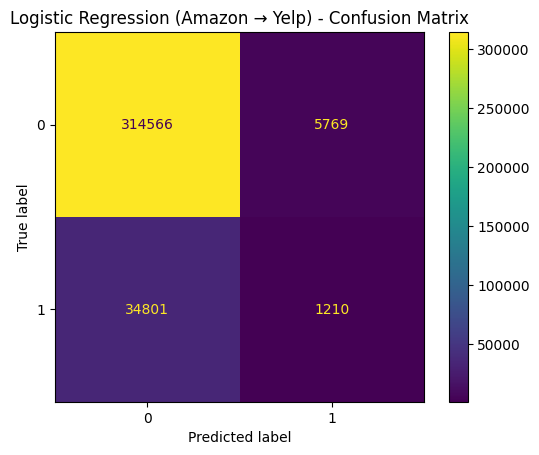

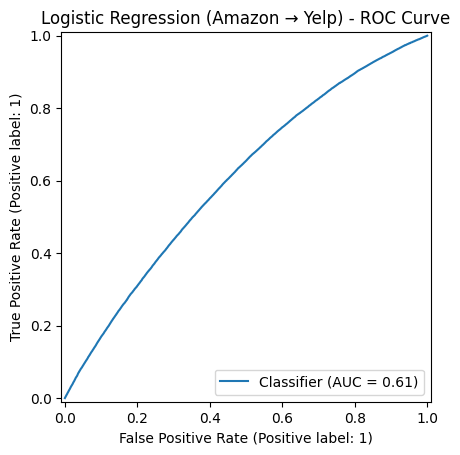


Linear SVM (Amazon → Yelp)
              precision    recall  f1-score   support

           0       0.90      0.98      0.94    320335
           1       0.17      0.04      0.07     36011

    accuracy                           0.88    356346
   macro avg       0.54      0.51      0.50    356346
weighted avg       0.83      0.88      0.85    356346



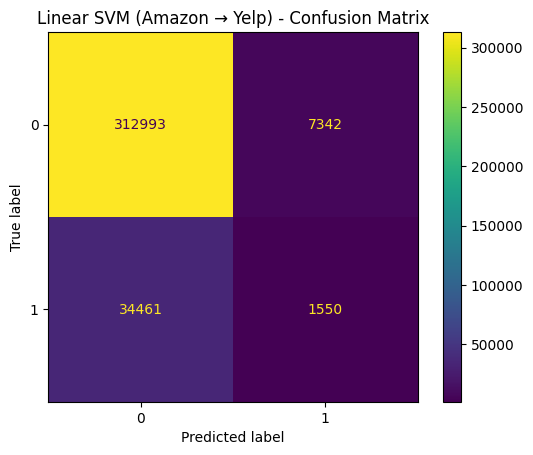

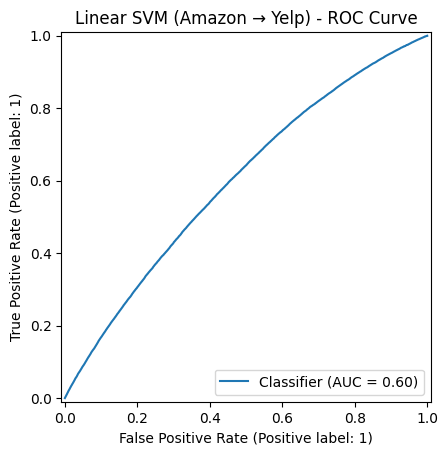


Random Forest (Amazon → Yelp)
              precision    recall  f1-score   support

           0       0.90      0.98      0.94    320335
           1       0.17      0.03      0.05     36011

    accuracy                           0.89    356346
   macro avg       0.54      0.51      0.49    356346
weighted avg       0.83      0.89      0.85    356346



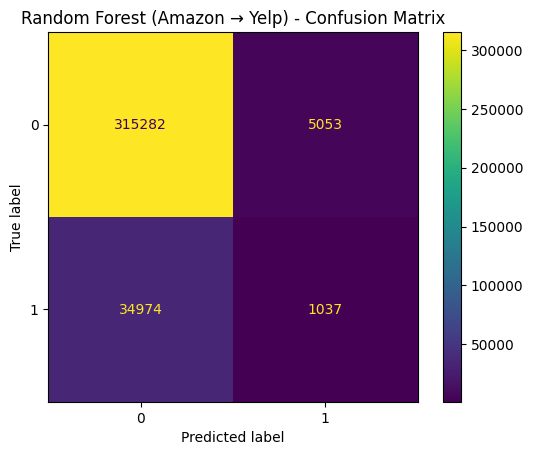

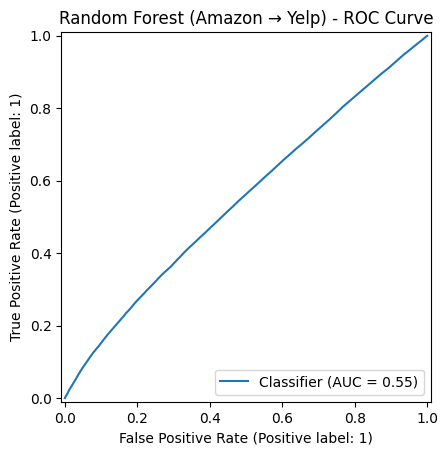


XGBoost (Amazon → Yelp)
              precision    recall  f1-score   support

           0       0.90      0.98      0.94    320335
           1       0.17      0.04      0.06     36011

    accuracy                           0.88    356346
   macro avg       0.53      0.51      0.50    356346
weighted avg       0.83      0.88      0.85    356346



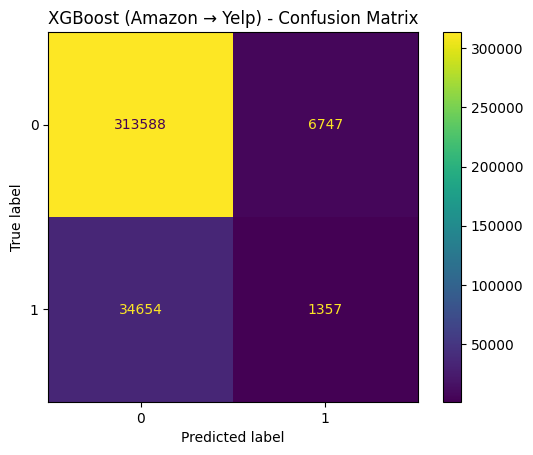

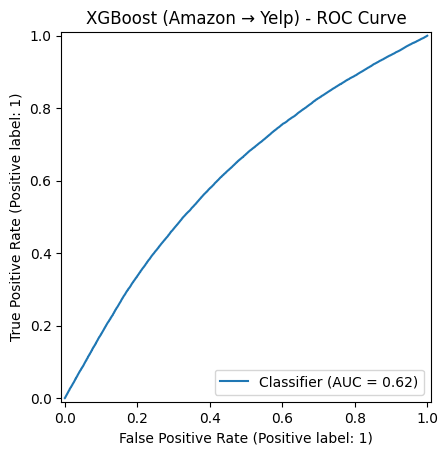

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (Amazon → Yelp),0.886150,0.173377,0.033601,0.056292,0.606040
1,Linear SVM (Amazon → Yelp),0.882690,0.174314,0.043042,0.069038,0.600111
2,Random Forest (Amazon → Yelp),0.887674,0.170279,0.028797,0.049262,0.548084
3,XGBoost (Amazon → Yelp),0.883818,0.167448,0.037683,0.061521,0.616268


In [112]:
results_A = []

for name, model in models.items():
    metrics = train_and_evaluate(
        model,
        X_train_A,
        y_train_A,
        X_test_A,
        y_test_A,
        f"{name} (Amazon → Yelp)"
    )

    results_A.append(metrics)

results_A = pd.DataFrame(results_A)
results_A


Logistic Regression (Yelp → Amazon)
              precision    recall  f1-score   support

           0       0.50      0.99      0.67     20215
           1       0.58      0.01      0.02     20193

    accuracy                           0.50     40408
   macro avg       0.54      0.50      0.34     40408
weighted avg       0.54      0.50      0.34     40408



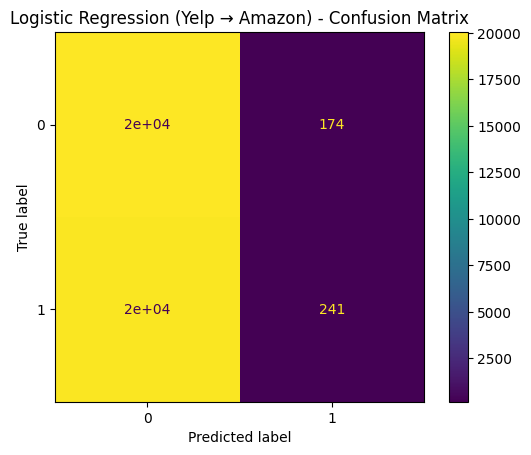

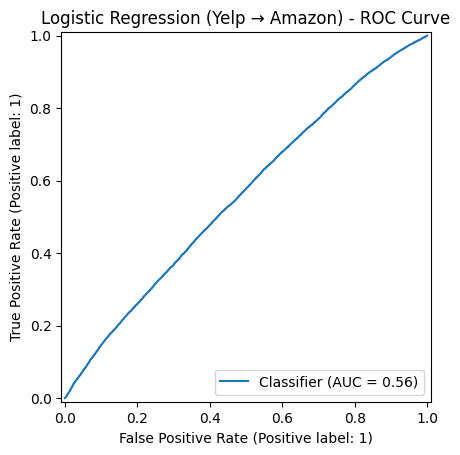


Linear SVM (Yelp → Amazon)
              precision    recall  f1-score   support

           0       0.50      1.00      0.67     20215
           1       0.47      0.00      0.01     20193

    accuracy                           0.50     40408
   macro avg       0.48      0.50      0.34     40408
weighted avg       0.48      0.50      0.34     40408



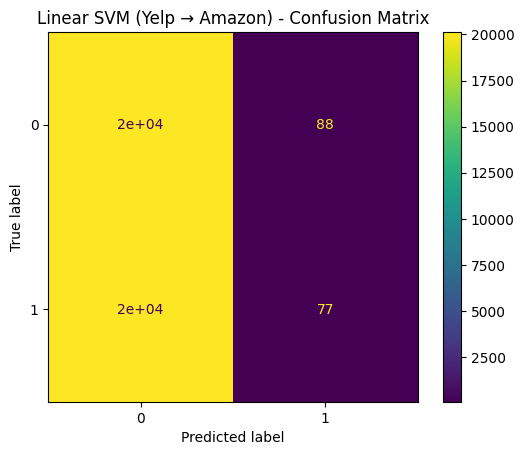

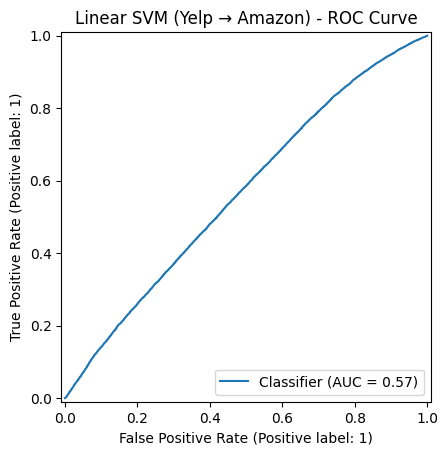


Random Forest (Yelp → Amazon)
              precision    recall  f1-score   support

           0       0.50      1.00      0.67     20215
           1       0.57      0.00      0.00     20193

    accuracy                           0.50     40408
   macro avg       0.54      0.50      0.33     40408
weighted avg       0.54      0.50      0.33     40408



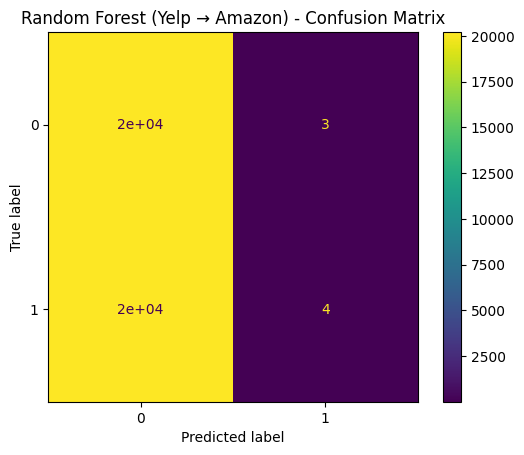

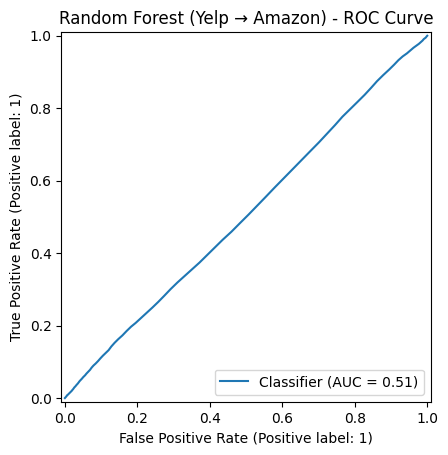


XGBoost (Yelp → Amazon)
              precision    recall  f1-score   support

           0       0.50      1.00      0.67     20215
           1       0.31      0.00      0.00     20193

    accuracy                           0.50     40408
   macro avg       0.40      0.50      0.33     40408
weighted avg       0.40      0.50      0.33     40408



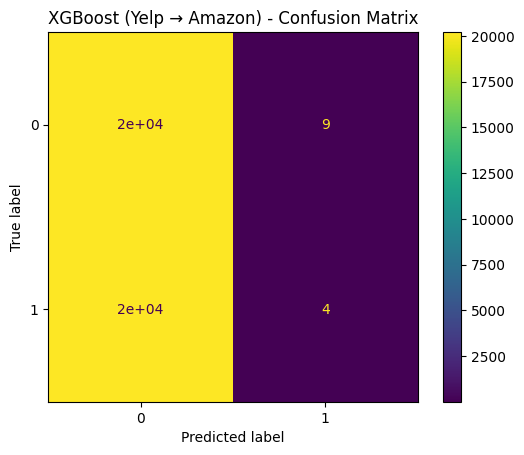

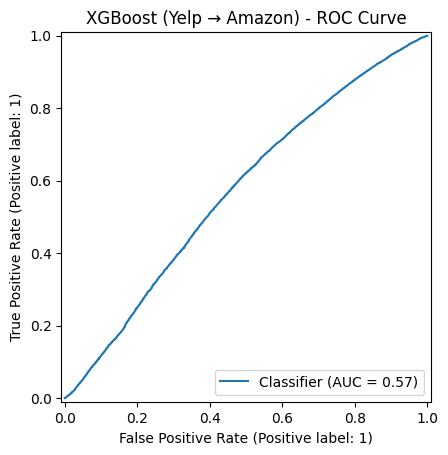

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (Yelp → Amazon),0.501930,0.580723,0.011935,0.023389,0.559852
1,Linear SVM (Yelp → Amazon),0.500000,0.466667,0.003813,0.007565,0.565538
2,Random Forest (Yelp → Amazon),0.500297,0.571429,0.000198,0.000396,0.506550
3,XGBoost (Yelp → Amazon),0.500148,0.307692,0.000198,0.000396,0.572188


In [113]:
results_B = []

for name, model in models.items():
    metrics = train_and_evaluate(
        model,
        X_train_B,
        y_train_B,
        X_test_B,
        y_test_B,
        f"{name} (Yelp → Amazon)"
    )

    results_B.append(metrics)

results_B = pd.DataFrame(results_B)
results_B

In [114]:
comparison = pd.concat(
    [
        results_A.assign(Experiment="Amazon → Yelp"),
        results_B.assign(Experiment="Yelp → Amazon")
    ],
    ignore_index=True
)

comparison = comparison.sort_values(
    ["Experiment", "F1 Score"],
    ascending=[True, False]
)

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Experiment
1,Linear SVM (Amazon → Yelp),0.8827,0.1743,0.0430,0.0690,0.6001,Amazon → Yelp
3,XGBoost (Amazon → Yelp),0.8838,0.1674,0.0377,0.0615,0.6163,Amazon → Yelp
0,Logistic Regression (Amazon → Yelp),0.8861,0.1734,0.0336,0.0563,0.6060,Amazon → Yelp
2,Random Forest (Amazon → Yelp),0.8877,0.1703,0.0288,0.0493,0.5481,Amazon → Yelp
4,Logistic Regression (Yelp → Amazon),0.5019,0.5807,0.0119,0.0234,0.5599,Yelp → Amazon
5,Linear SVM (Yelp → Amazon),0.5000,0.4667,0.0038,0.0076,0.5655,Yelp → Amazon
6,Random Forest (Yelp → Amazon),0.5003,0.5714,0.0002,0.0004,0.5066,Yelp → Amazon
7,XGBoost (Yelp → Amazon),0.5001,0.3077,0.0002,0.0004,0.5722,Yelp → Amazon


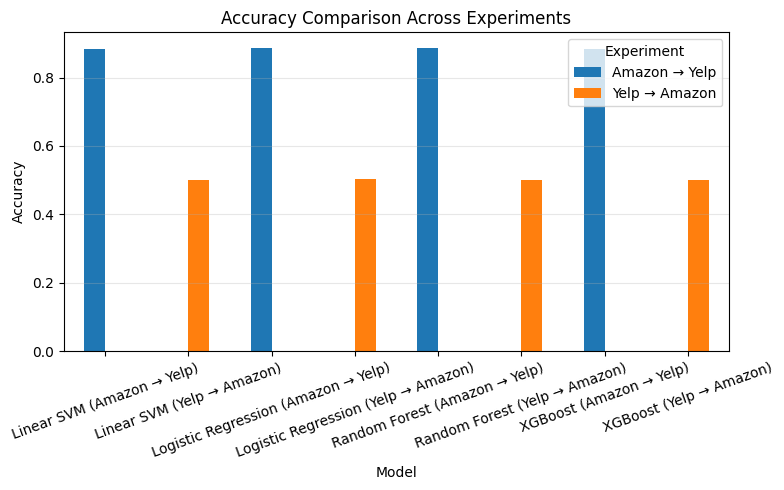

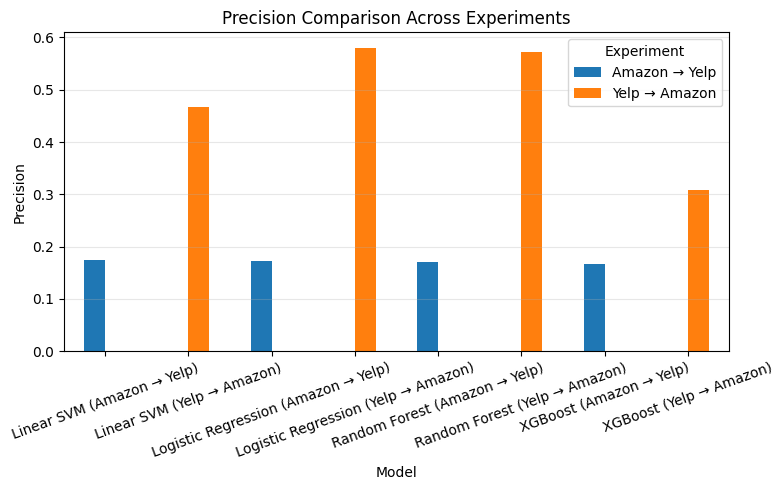

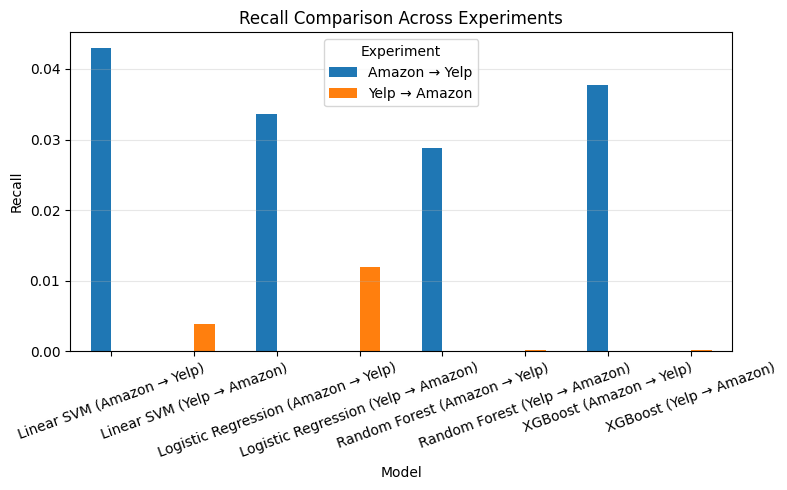

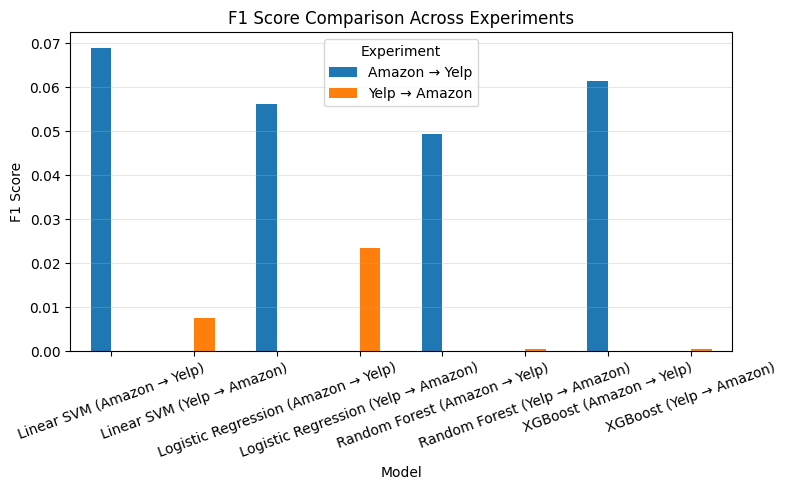

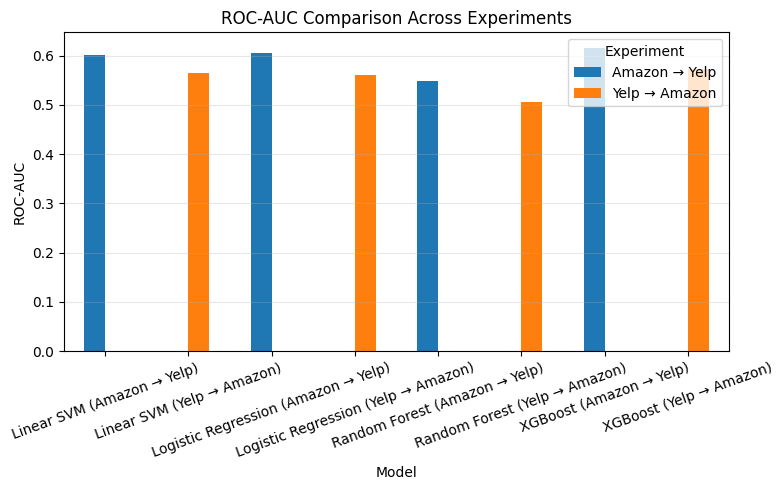

In [115]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

for metric in metrics_to_plot:
    pivot = comparison.pivot(
        index="Model",
        columns="Experiment",
        values=metric
    )

    pivot.plot(kind="bar", figsize=(8, 5))

    plt.title(f"{metric} Comparison Across Experiments")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

so it seems like training on yelp and testing it on amazon would be a better approach since we already have more yelp data than amazon